# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Basic setup
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

# Loading Data

In [3]:
# Load data
yougov = pd.read_csv("YouGov Data.csv")
oxcgrt = pd.read_csv("OxCGRT Data.csv")
owid = pd.read_csv("OWID Data.csv")

# EDA

In [4]:
# Ensure dates are datetime
yougov["date"] = pd.to_datetime(yougov["date"], errors="coerce")
oxcgrt["date"] = pd.to_datetime(oxcgrt["date"], errors="coerce")
owid["date"] = pd.to_datetime(owid["date"], errors="coerce")

In [5]:
# Variable group
y_vars = [
    "mask_wearing",
    "wash_hands",
    "use_sanitiser",
    "avoid_going_out",
    "avoid_public_transport",
    "avoid_crowded_areas",
    "would_self_isolate",
    "willingness_self_isolate"
]

x_yougov = [
    "age",
    "household_size",
    "handwashing_frequency",
    "times_left_home",
    "covid_dangerous_for_me",
    "likely_to_get_covid",
    "important_to_improve_health",
    "life_affected_by_covid",
    "trust_in_government_handling"
]

x_policy = [
    "mask_policy",
    "stay_home_requirement",
    "internal_movement_restriction",
    "gathering_restriction",
    "cancel_public_events",
    "workplace_closing",
    "public_transport_closure",
    "international_travel_controls",
    "public_information_campaign",
    "testing_policy",
    "contact_tracing",
    "stringency_index"
]

x_epi = [
    "new_cases_smoothed",
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed",
    "reproduction_rate",
    "people_fully_vaccinated_per_hundred",
    "hospital_patients",
    "icu_patients"
]

cat_yougov = ["gender", "state", "employment_status"]

In [6]:
# Prints basic dataset summary including shape, info, missing values, and statistics
def dataset_info(df, name):
    print(f"{name} Overview:")
    print("Shape:", df.shape)
    print("\nInfo:")
    print(df.info())
    
def dataset_description(df):
    print("Descriptive statistics:")
    display(df.describe(include="all").T)

def dataset_null_values(df):
    print("Missing values:")
    print(df.isna().sum().sort_values(ascending=False))


# Plots bar chart of top missing values across columns
def plot_missing_bar(df, name, top_n=25):
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0].head(top_n)
    if len(missing) == 0:
        print(f"No missing values to plot for {name}.")
        return
    plt.figure(figsize=(10, 5))
    missing.plot(kind="bar")
    plt.title(f"{name}: Missing Values by Column")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# Plots proportion-based bar charts for categorical or ordinal variables
def plot_count_percent(df, cols, title_prefix):
    for col in cols:
        if col in df.columns:
            temp = df[col].dropna()
            if temp.empty:
                continue
            counts = temp.value_counts(normalize=True).sort_index()
            plt.figure(figsize=(6, 4))
            counts.plot(kind="bar")
            plt.title(f"{title_prefix}: {col} (Proportion)")
            plt.xlabel(col)
            plt.ylabel("Proportion")
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.show()


# Plots histograms with KDE for numeric variables
def plot_histograms(df, cols, title_prefix, bins=30):
    for col in cols:
        if col in df.columns:
            temp = df[col].dropna()
            if temp.empty:
                continue
            plt.figure(figsize=(6, 4))
            sns.histplot(temp, bins=bins, kde=True)
            plt.title(f"{title_prefix}: {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")
            plt.tight_layout()
            plt.show()


# Plots boxplots to visualise distribution and outliers in numeric variables
def plot_boxplots(df, cols, title_prefix):
    for col in cols:
        if col in df.columns:
            temp = df[col].dropna()
            if temp.empty:
                continue
            plt.figure(figsize=(6, 3.5))
            sns.boxplot(x=temp)
            plt.title(f"{title_prefix}: {col}")
            plt.tight_layout()
            plt.show()


# Plots correlation heatmap for selected numeric variables
def plot_corr_heatmap(df, cols, title, figsize=(12, 8)):
    cols = [c for c in cols if c in df.columns]
    corr_df = df[cols].select_dtypes(include=np.number)
    if corr_df.shape[1] < 2:
        print(f"Not enough numeric columns for correlation heatmap: {title}")
        return
    plt.figure(figsize=figsize)
    sns.heatmap(corr_df.corr(), cmap="coolwarm", annot=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Plots daily average trends for selected variables
def plot_daily_means(df, cols, title_prefix):
    cols = [c for c in cols if c in df.columns]
    daily = df.groupby("date", as_index=False)[cols].mean(numeric_only=True)
    for col in cols:
        plt.figure(figsize=(10, 4))
        plt.plot(daily["date"], daily[col])
        plt.title(f"{title_prefix}: Daily Trend of {col}")
        plt.xlabel("Date")
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    return daily


# Plots weekly aggregated trends for selected variables
def plot_weekly_means(df, cols, title_prefix):
    cols = [c for c in cols if c in df.columns]
    temp = df.copy()
    temp["week"] = temp["date"].dt.to_period("W").apply(lambda r: r.start_time)
    weekly = temp.groupby("week", as_index=False)[cols].mean(numeric_only=True)
    for col in cols:
        plt.figure(figsize=(10, 4))
        plt.plot(weekly["week"], weekly[col])
        plt.title(f"{title_prefix}: Weekly Trend of {col}")
        plt.xlabel("Week")
        plt.ylabel(col)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    return weekly


# Daily time comparison plot
def plot_time_comparison(df, pairs, title_prefix):
    needed_cols = list(set([col for pair in pairs for col in pair]))
    needed_cols = [c for c in needed_cols if c in df.columns]

    daily = df.groupby("date", as_index=False)[needed_cols].mean(numeric_only=True)

    for col1, col2 in pairs:
        if col1 in daily.columns and col2 in daily.columns:
            plt.figure(figsize=(10, 4))
            plt.plot(daily["date"], daily[col1], label=col1)
            plt.plot(daily["date"], daily[col2], label=col2)
            plt.title(f"{title_prefix}: {col1} vs {col2}")
            plt.xlabel("Date")
            plt.ylabel("Value")
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


# Weekly time comparison plot
def plot_weekly_comparison(df, pairs, title_prefix):
    temp = df.copy()
    temp["week"] = temp["date"].dt.to_period("W").apply(lambda r: r.start_time)

    needed_cols = list(set([col for pair in pairs for col in pair]))
    needed_cols = [c for c in needed_cols if c in temp.columns]

    weekly = temp.groupby("week", as_index=False)[needed_cols].mean(numeric_only=True)

    for col1, col2 in pairs:
        if col1 in weekly.columns and col2 in weekly.columns:
            plt.figure(figsize=(10, 4))
            plt.plot(weekly["week"], weekly[col1], label=col1)
            plt.plot(weekly["week"], weekly[col2], label=col2)
            plt.title(f"{title_prefix}: {col1} vs {col2}")
            plt.xlabel("Week")
            plt.ylabel("Value")
            plt.legend()
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


# Scatter plot function
def plot_scatter_pairs(df, pairs, title_prefix, alpha=0.5):
    for x_col, y_col in pairs:
        if x_col in df.columns and y_col in df.columns:
            temp = df[[x_col, y_col]].dropna()
            if temp.empty:
                continue
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=temp, x=x_col, y=y_col, alpha=alpha)
            plt.title(f"{title_prefix}: {y_col} vs {x_col}")
            plt.tight_layout()
            plt.show()


# Boxplot by grouped/category variable
def plot_boxplot_pairs(df, pairs, title_prefix):
    for y_col, x_col in pairs:
        if x_col in df.columns and y_col in df.columns:
            temp = df[[x_col, y_col]].dropna()
            if temp.empty:
                continue
            plt.figure(figsize=(7, 4))
            sns.boxplot(data=temp, x=x_col, y=y_col)
            plt.title(f"{title_prefix}: {y_col} by {x_col}")
            plt.tight_layout()
            plt.show()


# Lag scatter plot
def plot_lag_scatter(df, y_col, x_col, lag_days=7, title_prefix="Lag Scatter"):
    if y_col not in df.columns or x_col not in df.columns:
        print(f"Columns not found: {y_col}, {x_col}")
        return

    temp = df[["date", y_col, x_col]].copy()
    temp = temp.sort_values("date")

    temp[f"{x_col}_lag_{lag_days}"] = temp[x_col].shift(lag_days)
    temp = temp[[y_col, f"{x_col}_lag_{lag_days}"]].dropna()

    if temp.empty:
        print(f"No data available for lag plot: {y_col} vs {x_col}")
        return

    plt.figure(figsize=(6, 4))
    sns.scatterplot(
        data=temp,
        x=f"{x_col}_lag_{lag_days}",
        y=y_col,
        alpha=0.5
    )
    plt.title(f"{title_prefix}: {y_col} vs {x_col} (lag {lag_days})")
    plt.tight_layout()
    plt.show()

## YouGov Data

In [7]:
# Data info
dataset_info(yougov, "YouGov")

YouGov Overview:
Shape: (53833, 23)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 53833 entries, 0 to 53832
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          53833 non-null  datetime64[us]
 1   survey_week                   53833 non-null  str           
 2   survey_weight                 53833 non-null  float64       
 3   age                           53833 non-null  int64         
 4   gender                        53833 non-null  str           
 5   state                         53833 non-null  str           
 6   household_size                53833 non-null  int64         
 7   employment_status             53833 non-null  str           
 8   mask_wearing                  53833 non-null  int64         
 9   wash_hands                    52827 non-null  float64       
 10  use_sanitiser                 53833 non-null  int64         
 

In [8]:
# Data description
dataset_description(yougov)

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,53833,NaN,NaN,NaN,2021-03-13 02:07:29.256032,2020-04-01 00:00:00,2020-08-21 00:00:00,2021-03-18 00:00:00,2021-09-21 00:00:00,2022-03-28 00:00:00,NaN
survey_week,53833,54,week 45,1021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
survey_weight,53833.0,NaN,NaN,NaN,1.000001,0.40286,0.849908,0.958053,1.100902,7.960737,0.275369
age,53833.0,NaN,NaN,NaN,47.487601,18.0,33.0,46.0,62.0,98.0,17.057463
gender,53833,2,Female,27654,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,53833,8,New South Wales,16473,NaN,NaN,NaN,NaN,NaN,NaN,NaN
household_size,53833.0,NaN,NaN,NaN,2.668605,1.0,2.0,2.0,4.0,8.0,1.365631
employment_status,53833,10,Full time employment,18219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mask_wearing,53833.0,NaN,NaN,NaN,3.195493,1.0,1.0,4.0,5.0,5.0,1.745271
wash_hands,52827.0,NaN,NaN,NaN,4.505953,1.0,4.0,5.0,5.0,5.0,0.839626


In [9]:
# Null values
dataset_null_values(yougov)

Missing values:
would_self_isolate              5635
willingness_self_isolate        2068
wash_hands                      1006
age                                0
date                               0
survey_week                        0
survey_weight                      0
household_size                     0
state                              0
gender                             0
mask_wearing                       0
use_sanitiser                      0
avoid_going_out                    0
avoid_public_transport             0
employment_status                  0
avoid_crowded_areas                0
handwashing_frequency              0
times_left_home                    0
covid_dangerous_for_me             0
likely_to_get_covid                0
important_to_improve_health        0
life_affected_by_covid             0
trust_in_government_handling       0
dtype: int64


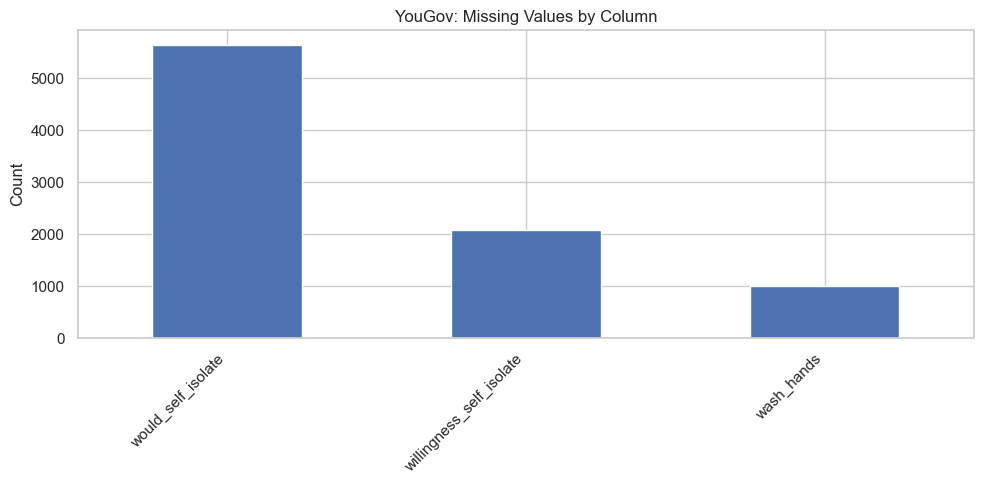

In [10]:
# Plot for null vlaues
plot_missing_bar(yougov, "YouGov")

In [11]:
# Categorical summaries
for col in cat_yougov:
    if col in yougov.columns:
        print(f"\nValue counts for {col}:")
        print(yougov[col].value_counts(dropna=False))


Value counts for gender:
gender
Female    27654
Male      26179
Name: count, dtype: int64

Value counts for state:
state
New South Wales                 16473
Victoria                        13899
Queensland                      10963
Western Australia                5093
South Australia                  5060
Tasmania                         1124
Australian Capital Territory      859
Northern Territory                362
Name: count, dtype: int64

Value counts for employment_status:
employment_status
Full time employment                             18219
Part time employment                             12085
Retired                                          11094
Unemployed                                        5939
Not working                                       5726
Working full time (35 or more hours per week)      362
Working part time (8-34 hours a week)              162
Not working - looking for work                     120
Not working - not looking for work                  8

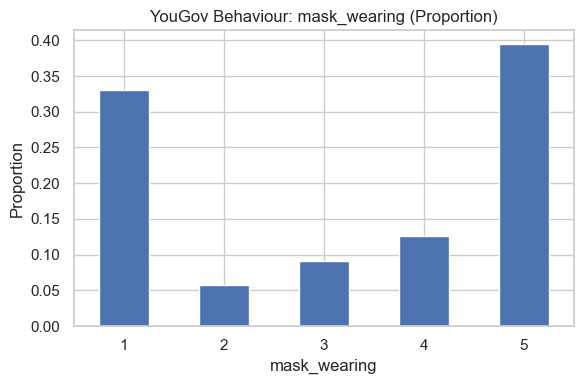

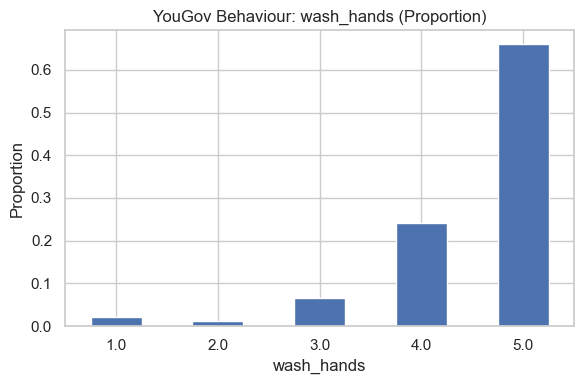

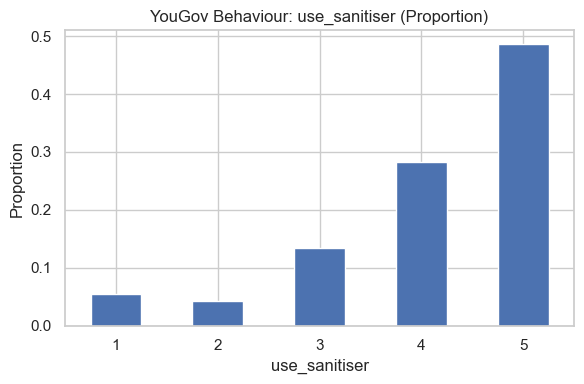

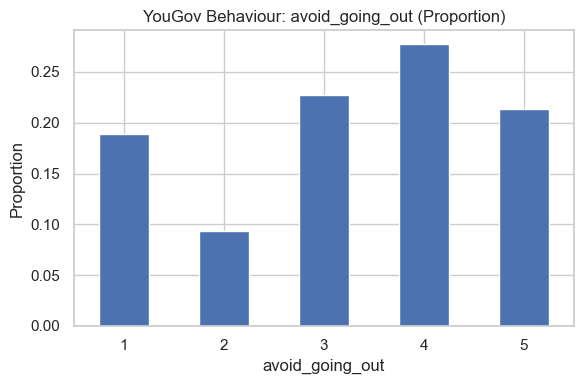

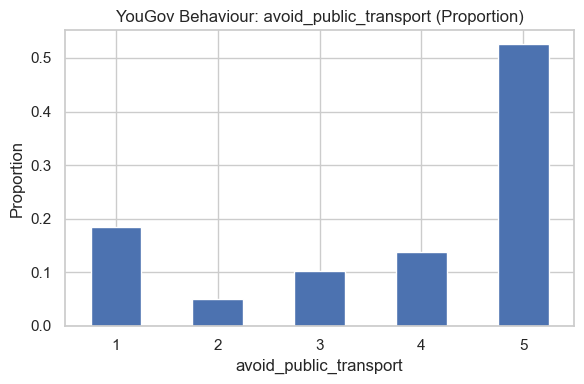

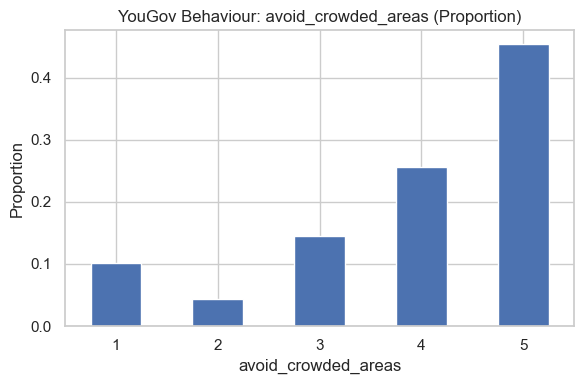

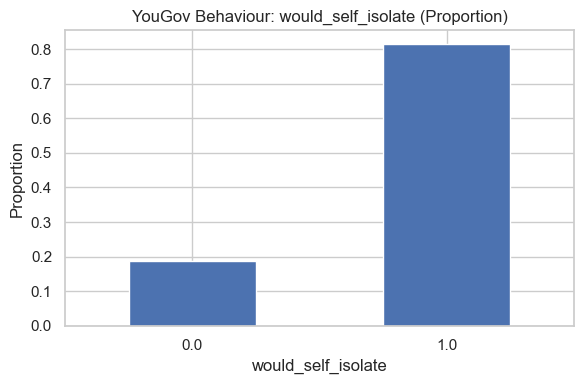

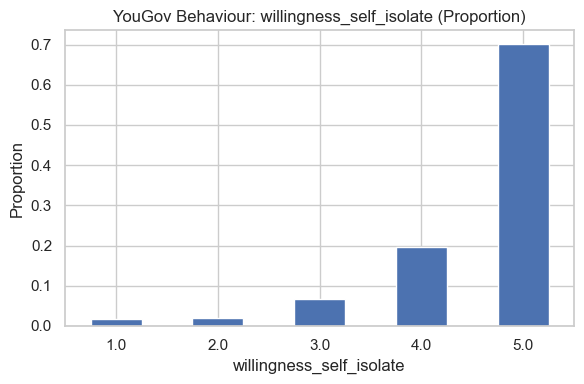

In [12]:
# Behaviour variables
plot_count_percent(yougov, y_vars, "YouGov Behaviour")

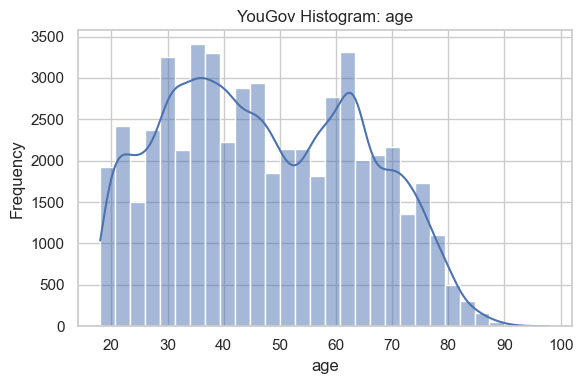

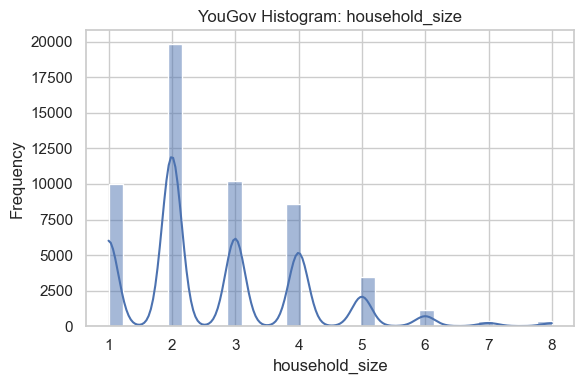

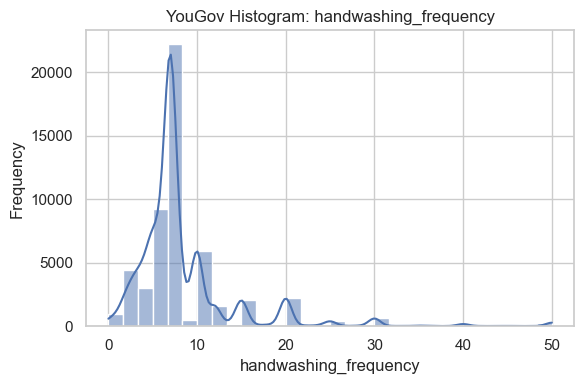

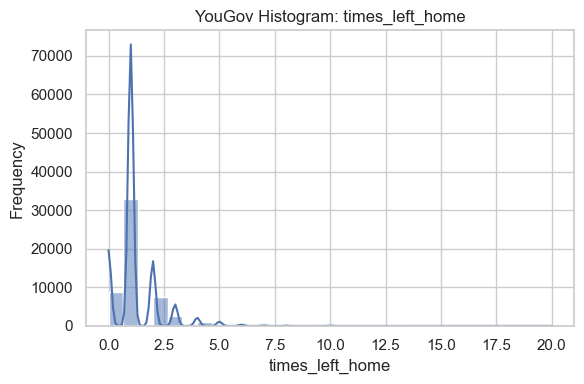

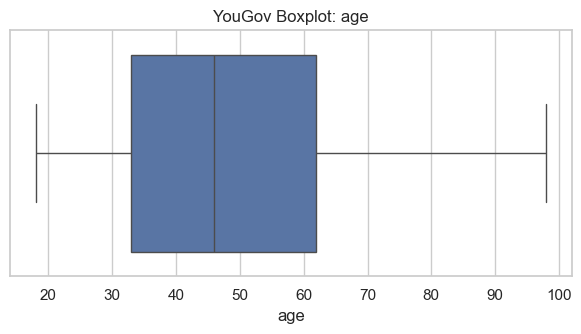

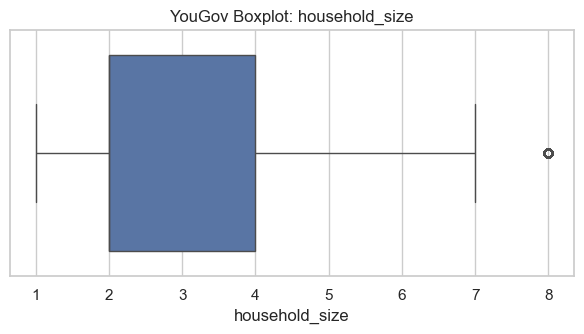

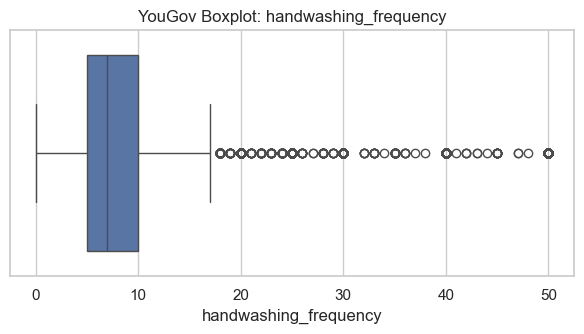

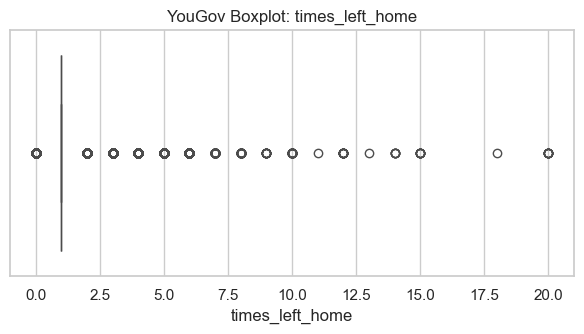

In [13]:
# Numeric / continuous variables
plot_histograms(yougov, ["age", "household_size", "handwashing_frequency", "times_left_home"], "YouGov Histogram")
plot_boxplots(yougov, ["age", "household_size", "handwashing_frequency", "times_left_home"], "YouGov Boxplot")

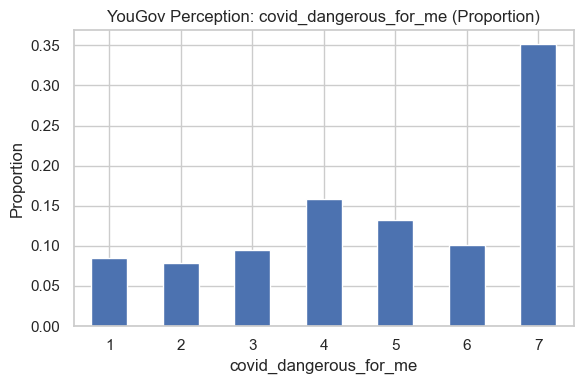

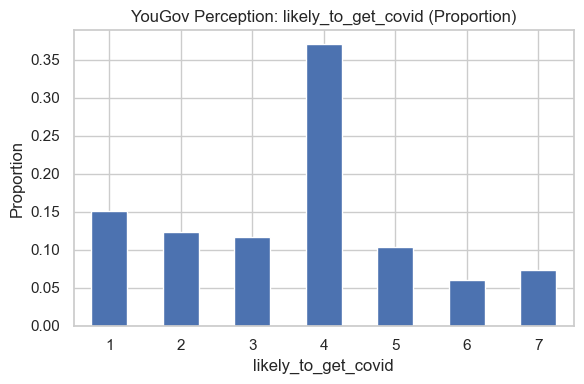

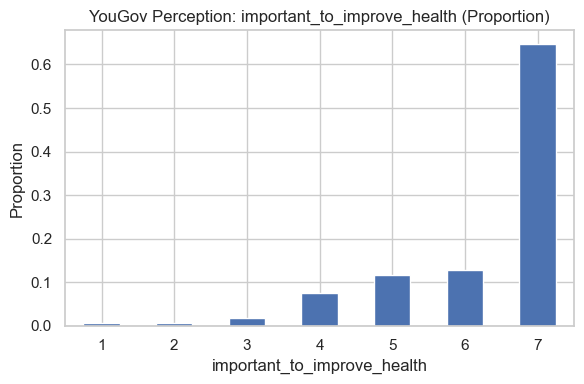

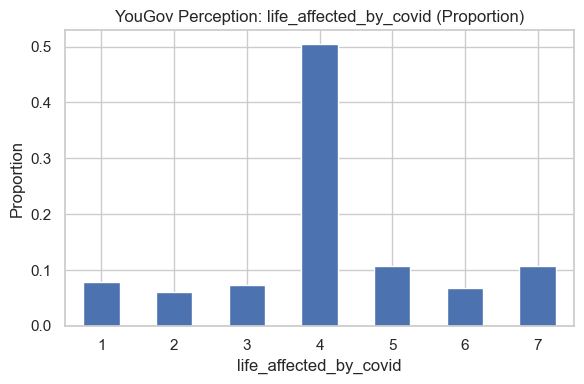

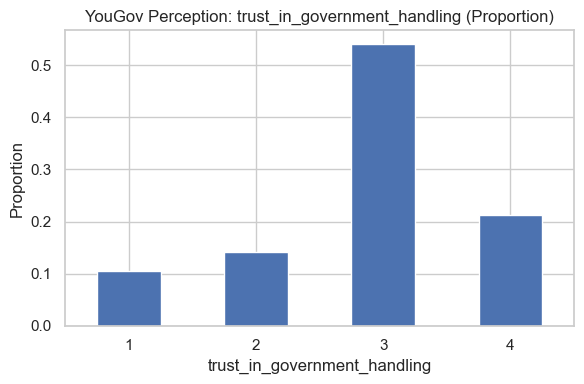

In [14]:
# Perception distributions
plot_count_percent(
    yougov,
    [
        "covid_dangerous_for_me",
        "likely_to_get_covid",
        "important_to_improve_health",
        "life_affected_by_covid",
        "trust_in_government_handling"
        ],
    "YouGov Perception"
)

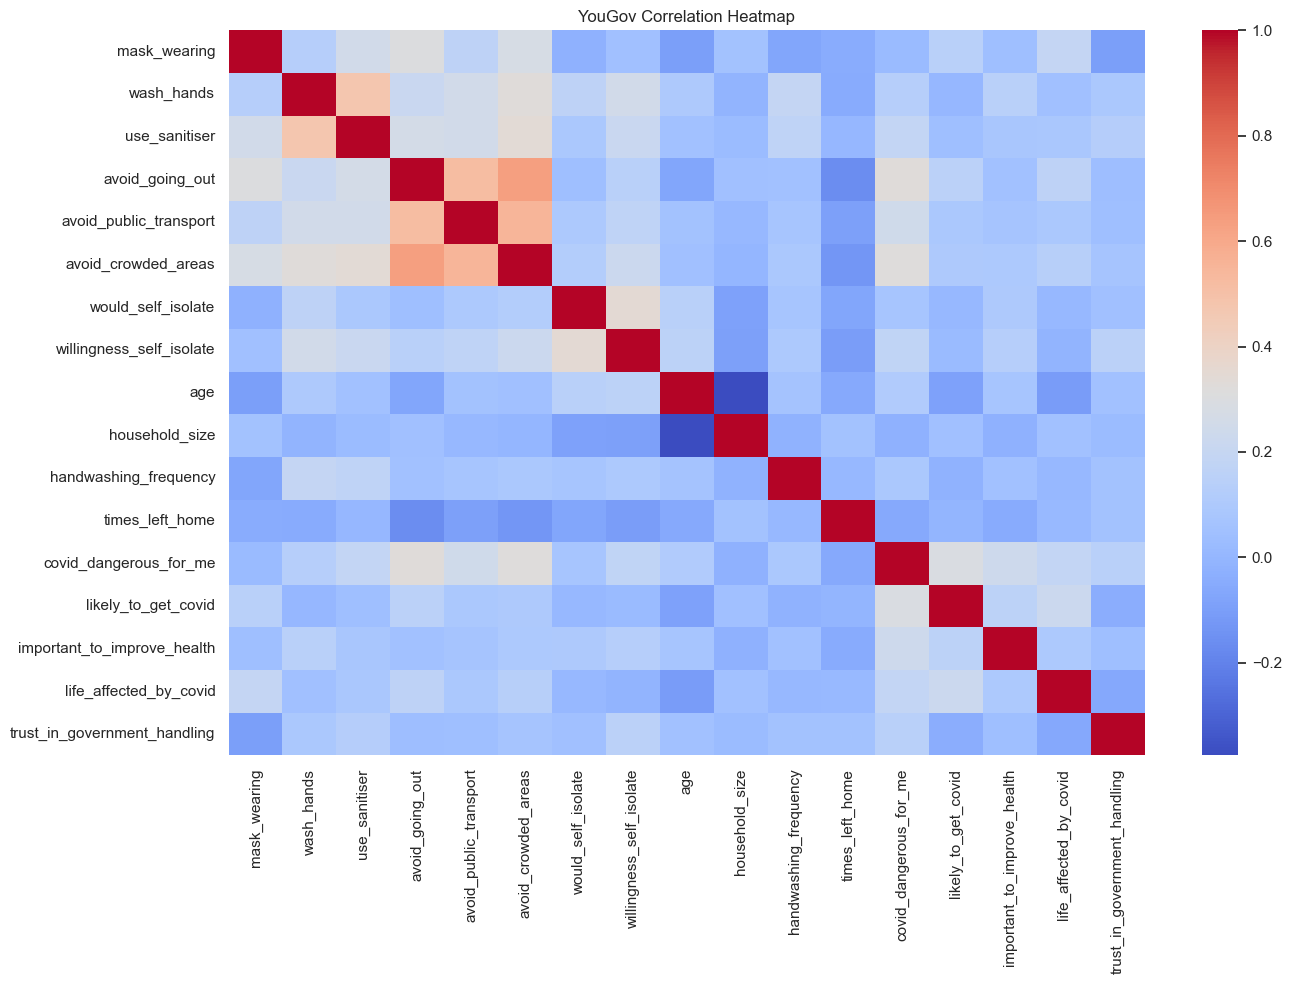

In [15]:
# Correlation heatmap
plot_corr_heatmap(
    yougov,
    y_vars + x_yougov,
    "YouGov Correlation Heatmap",
    figsize=(14, 10)
)

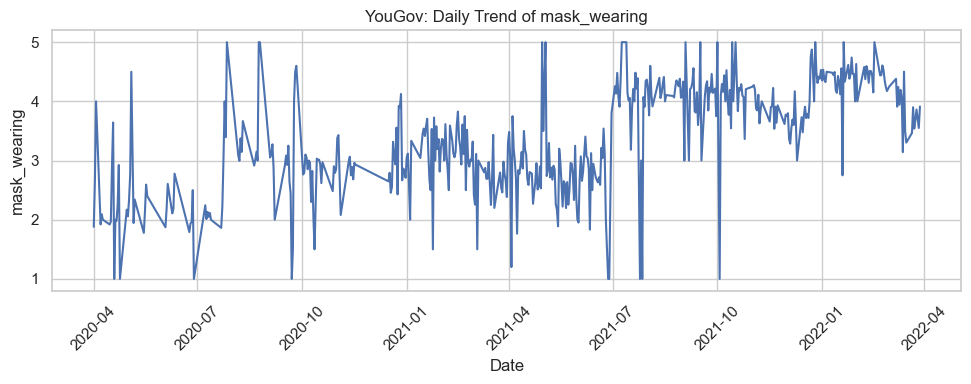

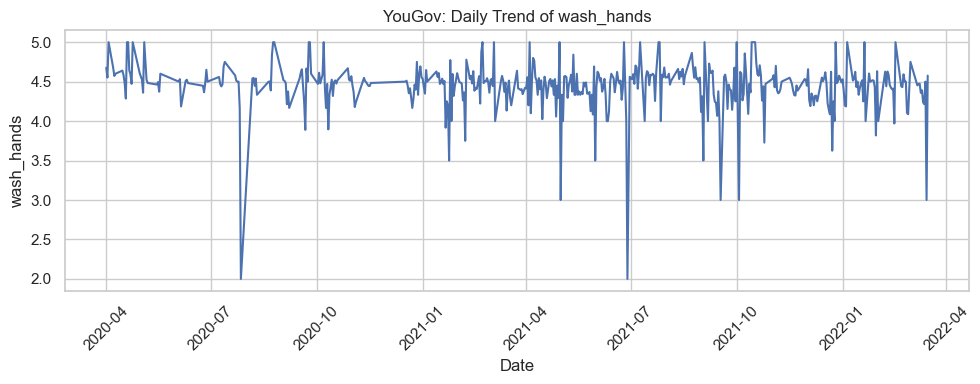

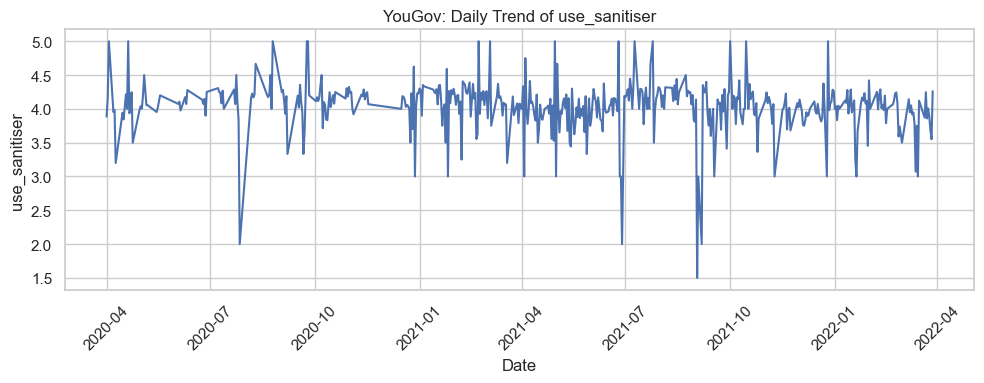

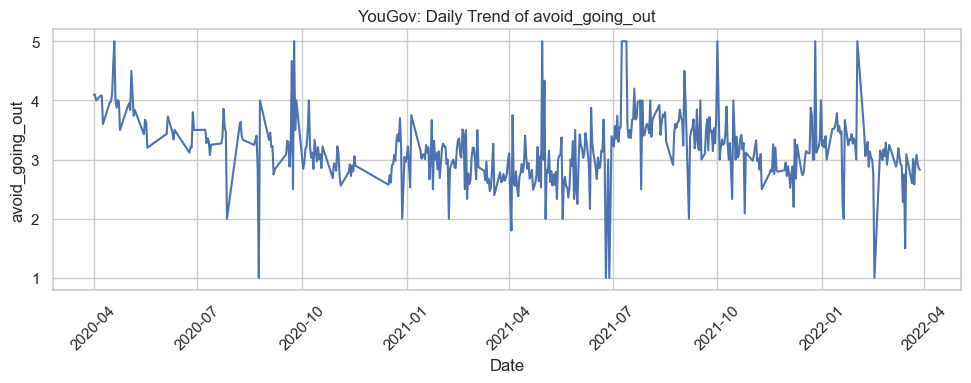

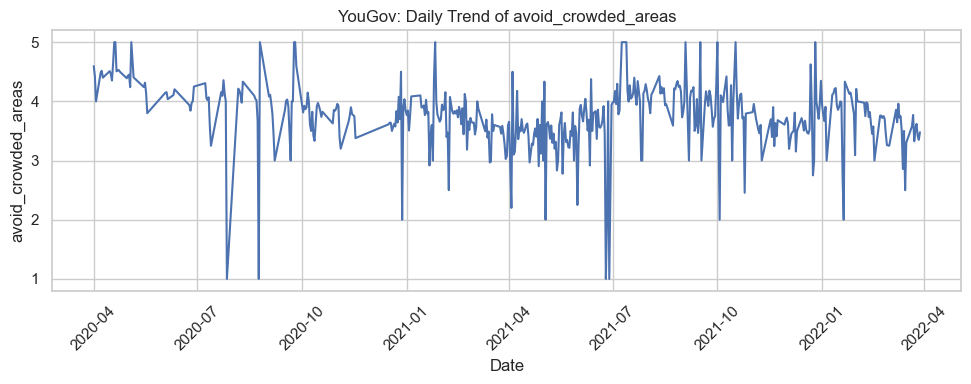

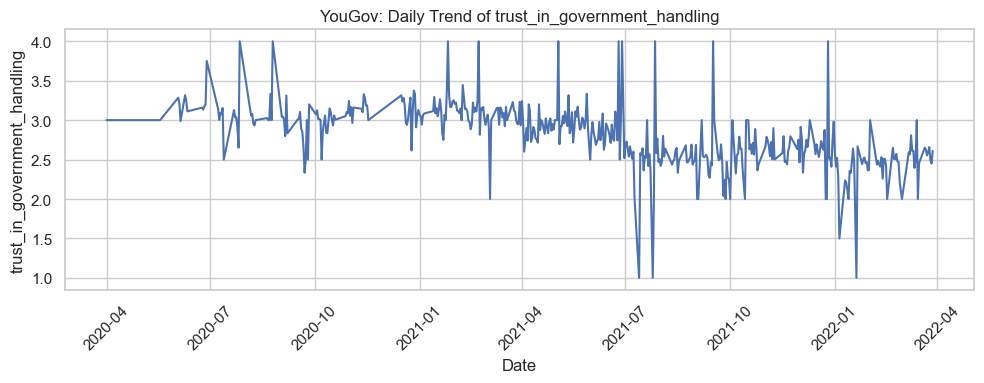

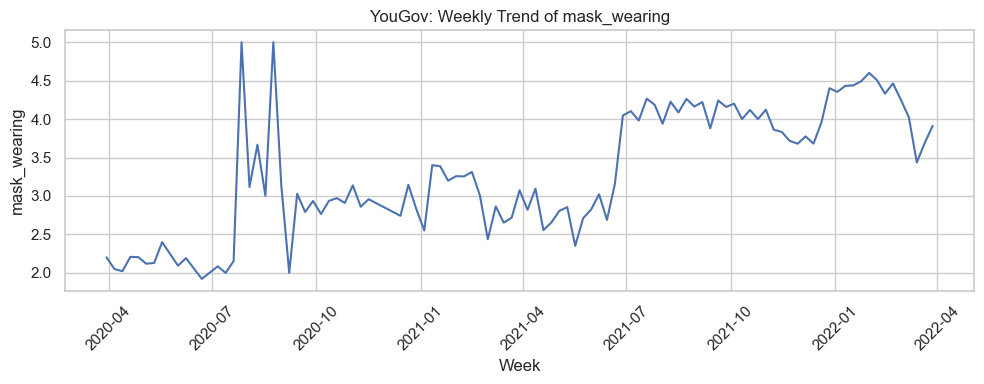

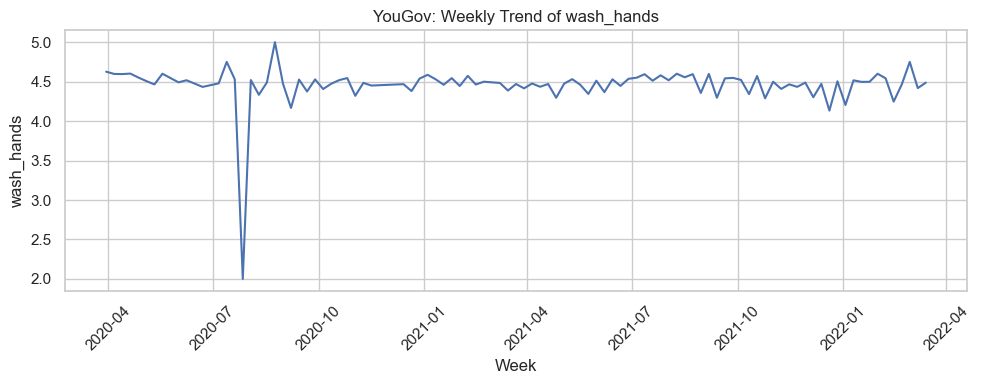

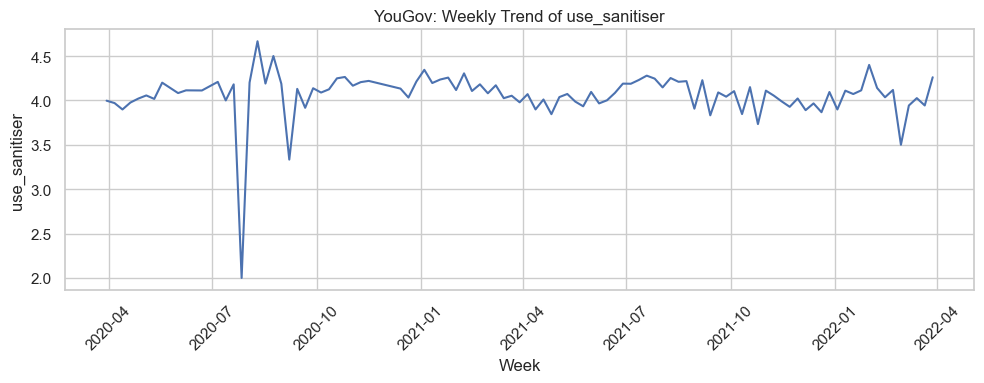

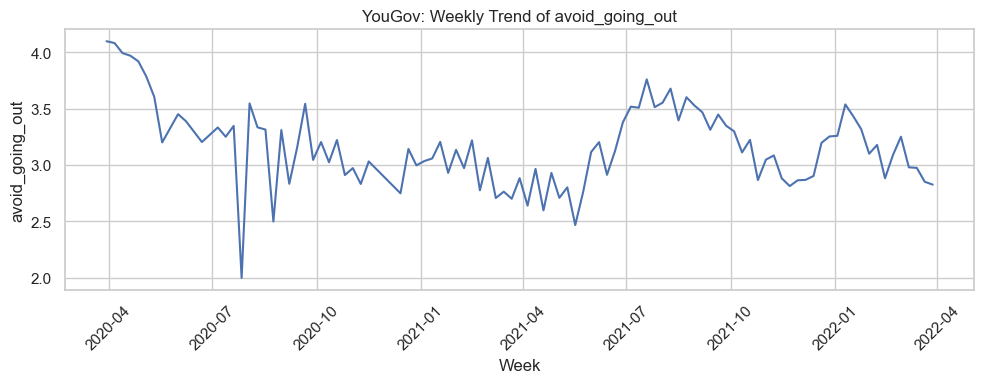

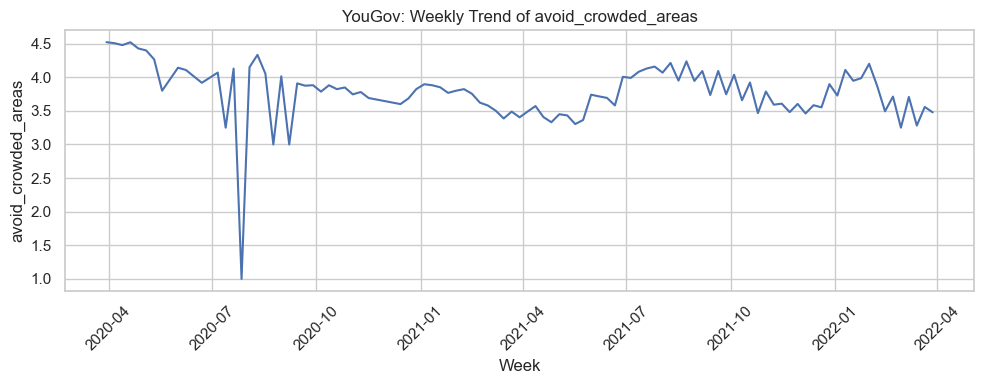

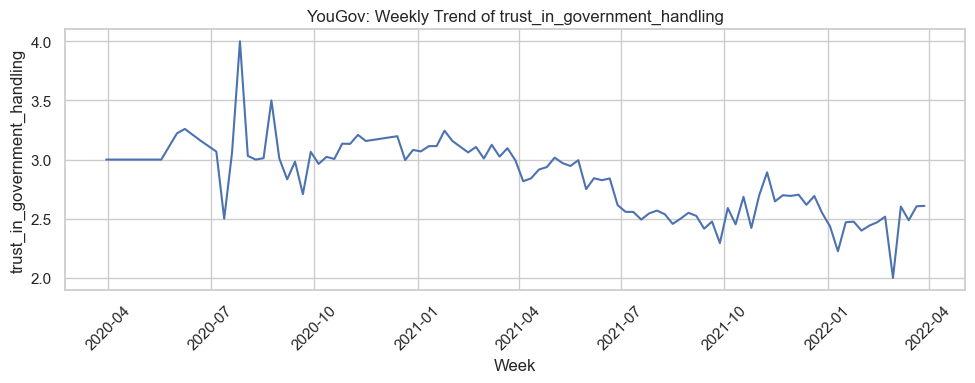

In [16]:
# Time trends
yougov_daily = plot_daily_means(
    yougov,
    [
        "mask_wearing",
        "wash_hands",
        "use_sanitiser",
        "avoid_going_out",
        "avoid_crowded_areas",
        "trust_in_government_handling"
    ],
    "YouGov"
)

yougov_weekly = plot_weekly_means(
    yougov,
    [
        "mask_wearing",
        "wash_hands",
        "use_sanitiser",
        "avoid_going_out",
        "avoid_crowded_areas",
        "trust_in_government_handling"
    ],
    "YouGov"
)

## OxCGRT Data

In [17]:
# Data info
dataset_info(oxcgrt, "OxCGRT")

OxCGRT Overview:
Shape: (1096, 13)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   date                           1096 non-null   datetime64[us]
 1   mask_policy                    1096 non-null   int64         
 2   stay_home_requirement          1096 non-null   int64         
 3   internal_movement_restriction  1096 non-null   int64         
 4   gathering_restriction          1096 non-null   int64         
 5   cancel_public_events           1096 non-null   int64         
 6   workplace_closing              1096 non-null   int64         
 7   public_transport_closure       1096 non-null   int64         
 8   international_travel_controls  1096 non-null   int64         
 9   public_information_campaign    1096 non-null   int64         
 10  testing_policy                 1096 non-null   int64 

In [18]:
# Data description
dataset_description(oxcgrt)

Descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
date,1096,2021-07-01 12:00:00,2020-01-01 00:00:00,2020-09-30 18:00:00,2021-07-01 12:00:00,2022-04-01 06:00:00,2022-12-31 00:00:00,NaN
mask_policy,1096.0,1.963504,0.0,0.0,2.0,3.0,4.0,1.404669
stay_home_requirement,1096.0,0.778285,0.0,0.0,0.0,2.0,3.0,0.951386
internal_movement_restriction,1096.0,1.380474,0.0,0.0,2.0,2.0,2.0,0.909786
gathering_restriction,1096.0,2.673358,0.0,0.0,4.0,4.0,4.0,1.717241
cancel_public_events,1096.0,1.166971,0.0,0.0,1.0,2.0,2.0,0.828953
workplace_closing,1096.0,1.383212,0.0,0.0,1.0,2.0,3.0,1.090034
public_transport_closure,1096.0,0.666058,0.0,0.0,1.0,1.0,1.0,0.471834
international_travel_controls,1096.0,2.632299,0.0,1.0,4.0,4.0,4.0,1.646032
public_information_campaign,1096.0,1.947993,0.0,2.0,2.0,2.0,2.0,0.305259


In [19]:
# Null values
dataset_null_values(oxcgrt)

Missing values:
date                             0
mask_policy                      0
stay_home_requirement            0
internal_movement_restriction    0
gathering_restriction            0
cancel_public_events             0
workplace_closing                0
public_transport_closure         0
international_travel_controls    0
public_information_campaign      0
testing_policy                   0
contact_tracing                  0
stringency_index                 0
dtype: int64


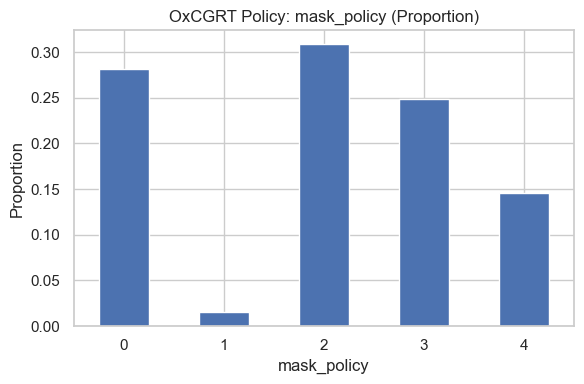

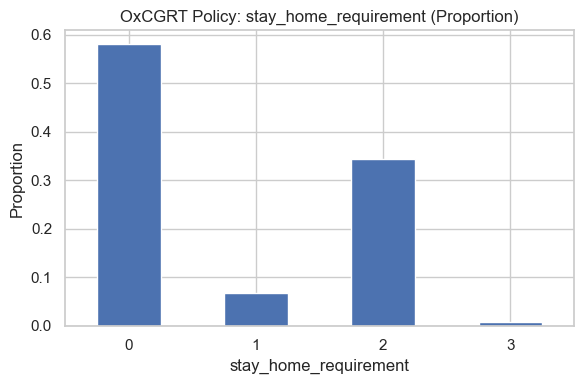

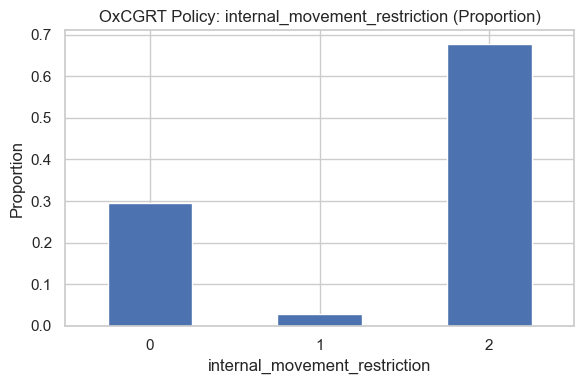

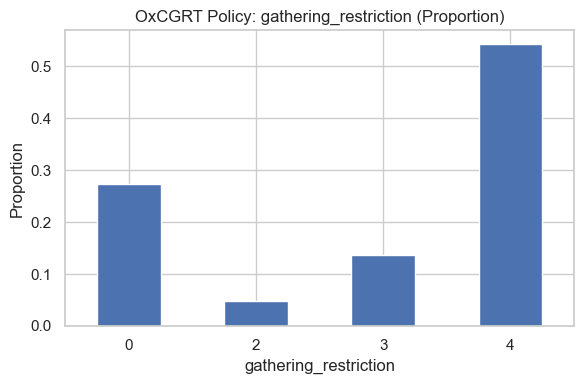

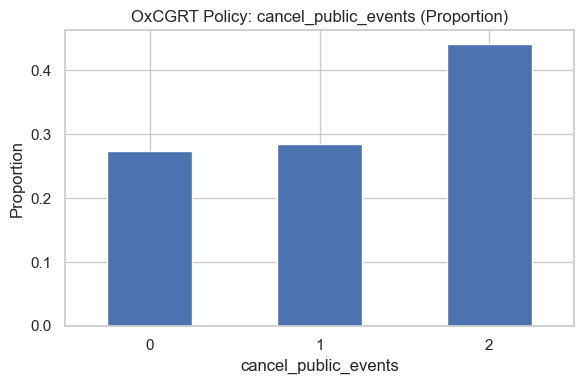

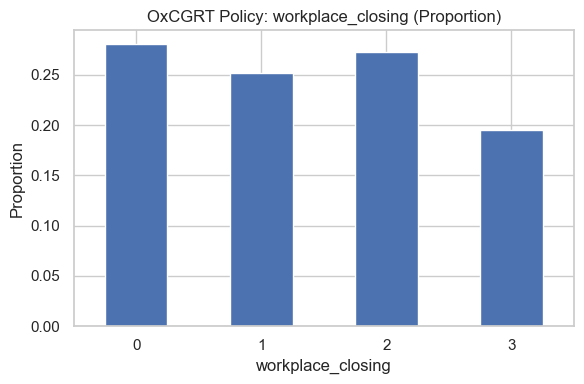

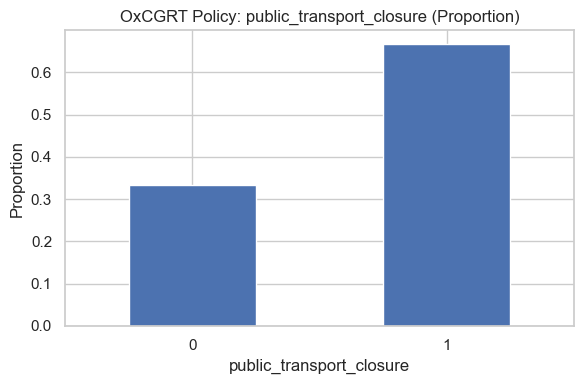

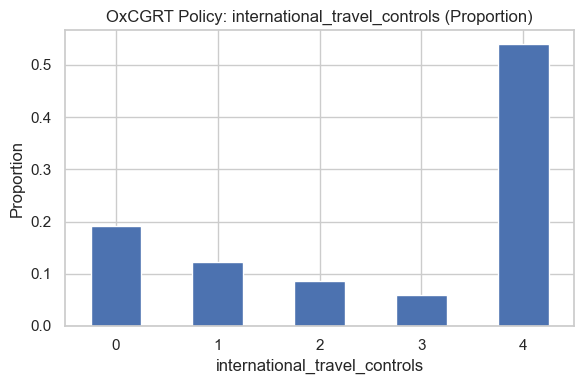

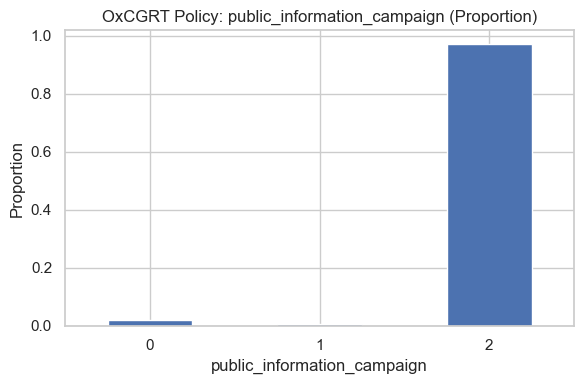

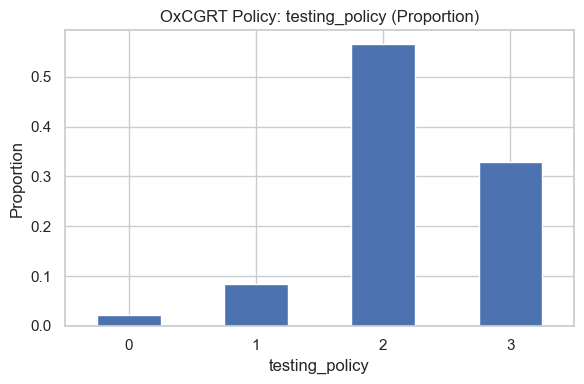

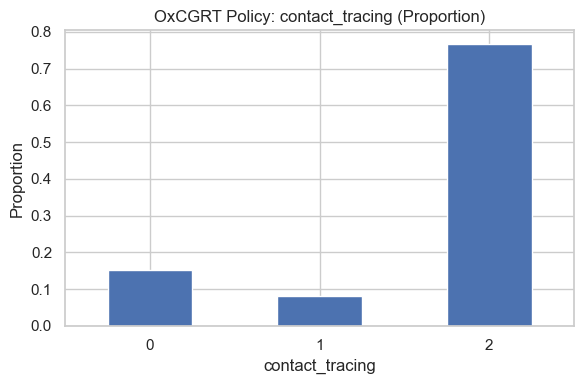

In [20]:
# Policy varibales
plot_count_percent(oxcgrt, x_policy[:-1], "OxCGRT Policy")

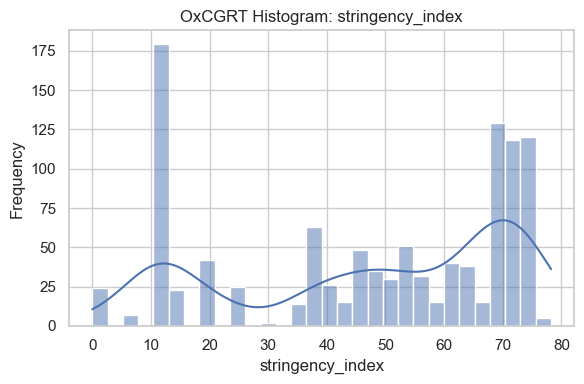

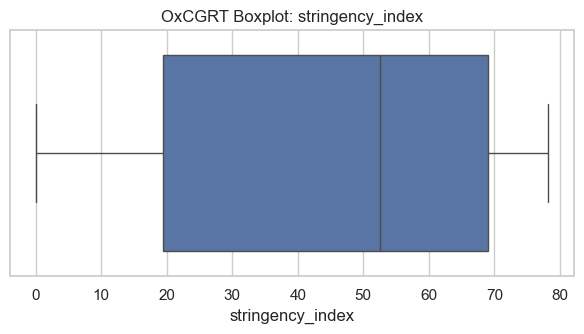

In [21]:
# # Numeric / continuous variables
plot_histograms(oxcgrt, ["stringency_index"], "OxCGRT Histogram")
plot_boxplots(oxcgrt, ["stringency_index"], "OxCGRT Boxplot")

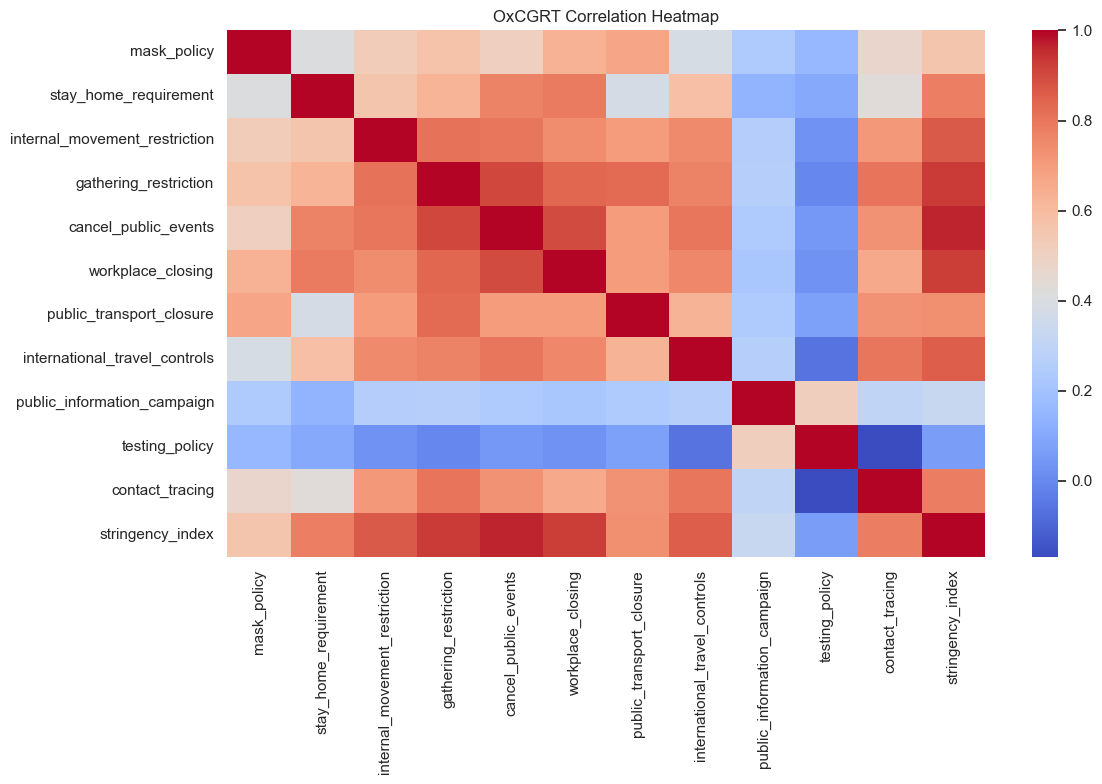

In [22]:
# Correlation heatmap
plot_corr_heatmap(
    oxcgrt,
    x_policy,
    "OxCGRT Correlation Heatmap",
    figsize=(12, 8)
)

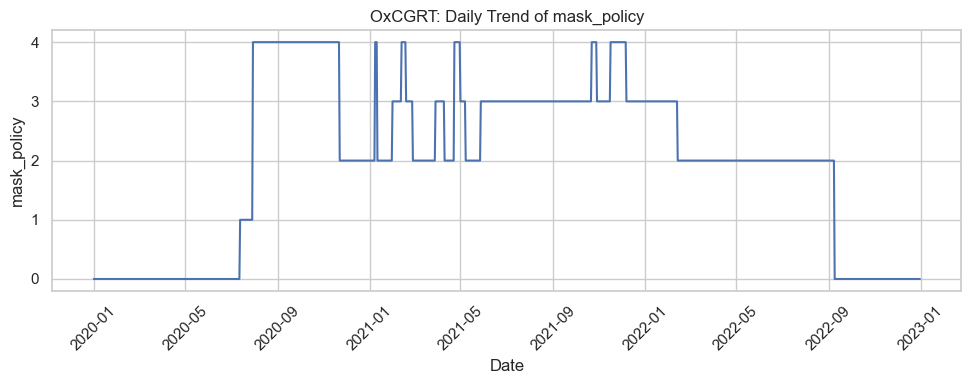

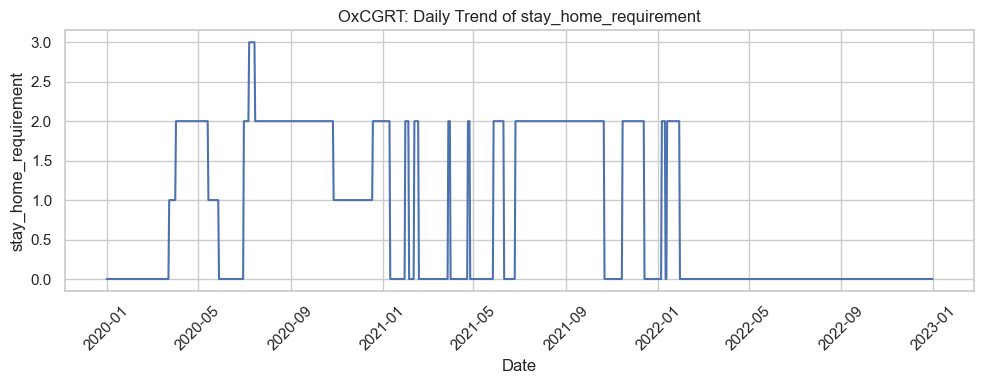

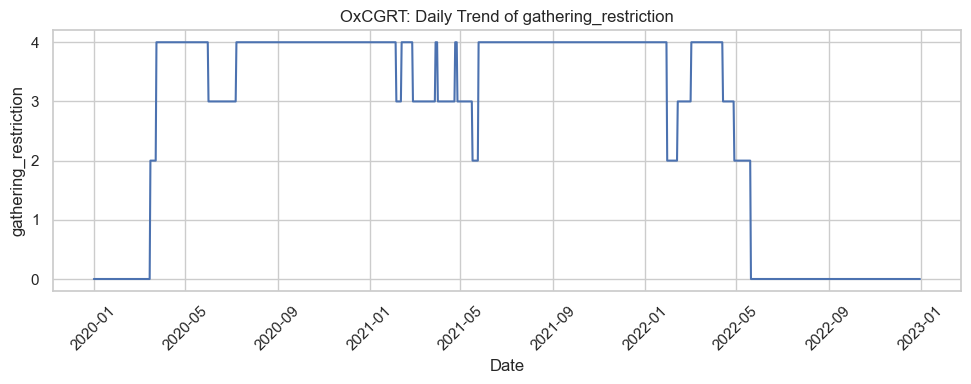

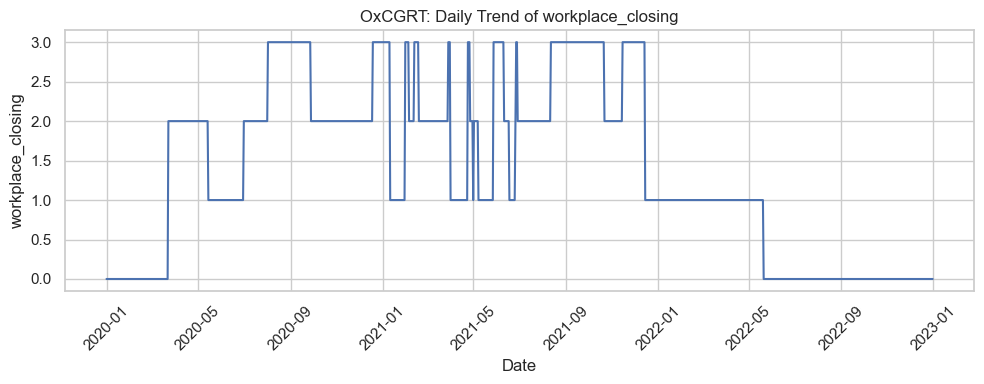

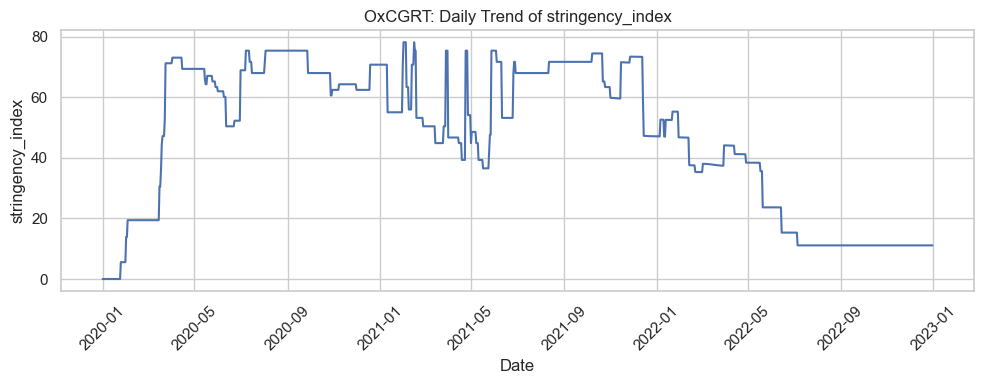

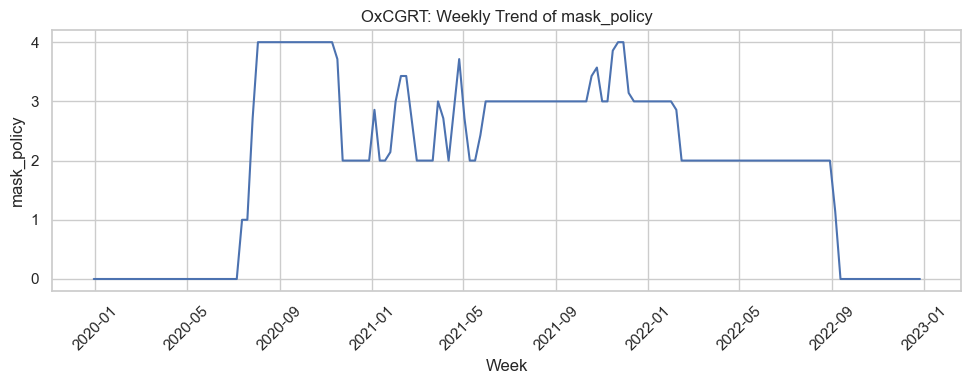

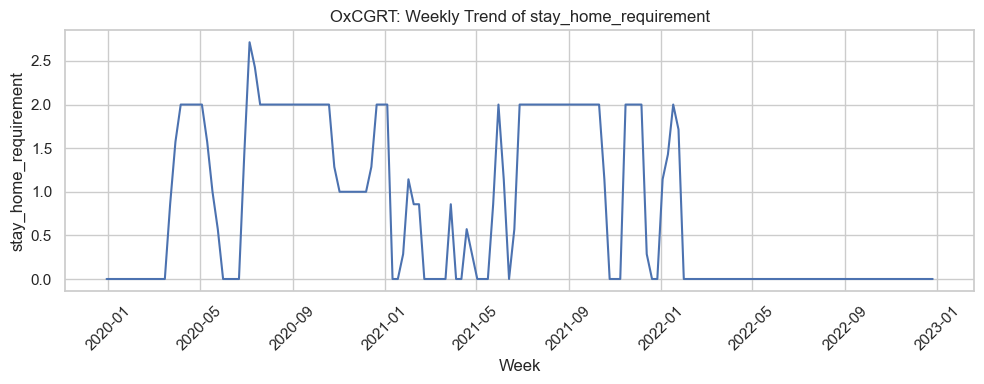

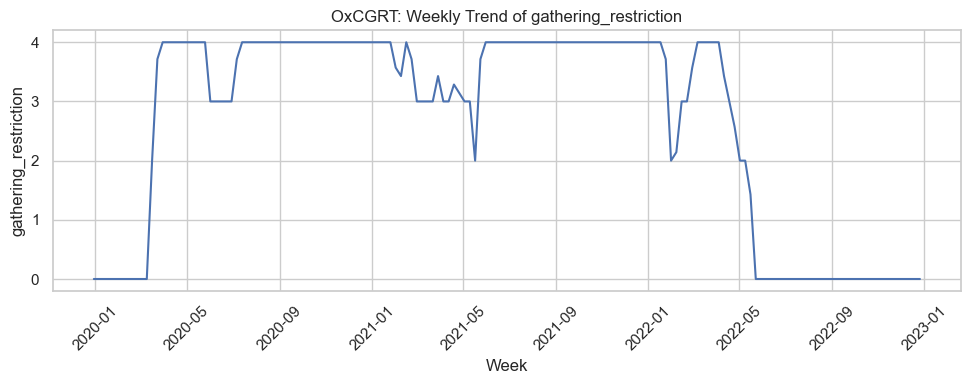

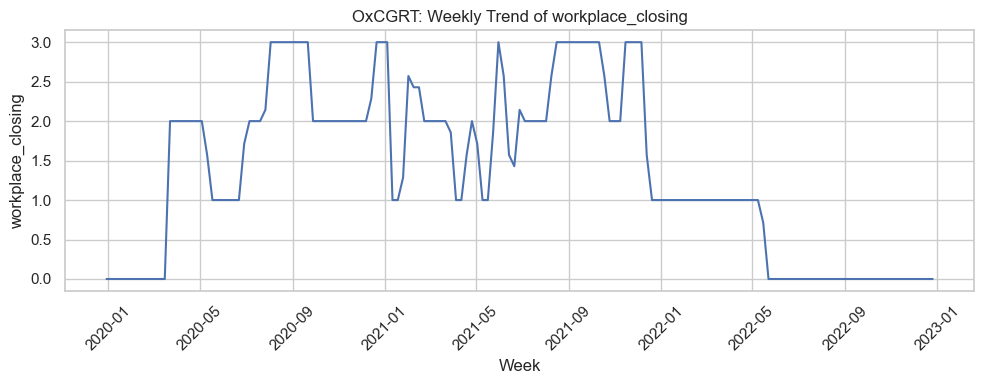

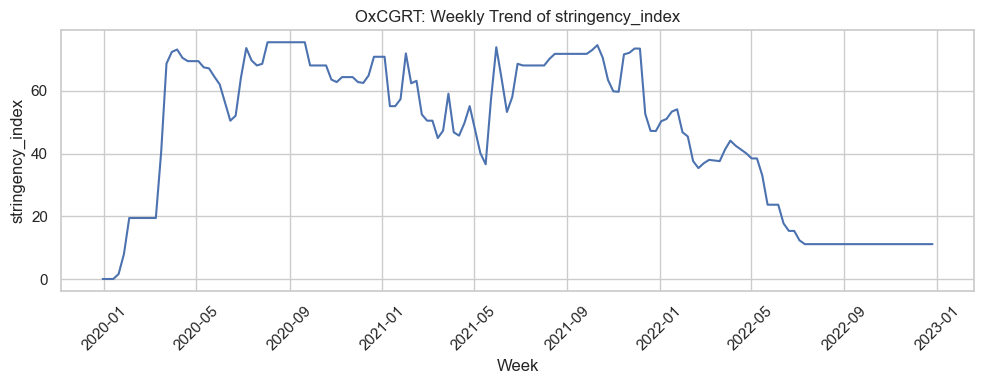

In [23]:
# Time trend
oxcgrt_daily = plot_daily_means(
    oxcgrt,
    [
        "mask_policy",
        "stay_home_requirement",
        "gathering_restriction",
        "workplace_closing",
        "stringency_index"
    ],
    "OxCGRT"
)

oxcgrt_weekly = plot_weekly_means(
    oxcgrt,
    [
        "mask_policy",
        "stay_home_requirement",
        "gathering_restriction",
        "workplace_closing",
        "stringency_index"
    ],
    "OxCGRT"
)

## OWID Data

In [24]:
# Data info
dataset_info(owid, "OWID")

OWID Overview:
Shape: (1674, 8)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1674 entries, 0 to 1673
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   date                                 1674 non-null   datetime64[us]
 1   new_cases_smoothed                   1674 non-null   float64       
 2   new_cases_smoothed_per_million       1674 non-null   float64       
 3   new_deaths_smoothed                  1674 non-null   float64       
 4   reproduction_rate                    1674 non-null   float64       
 5   people_fully_vaccinated_per_hundred  1674 non-null   float64       
 6   hospital_patients                    1674 non-null   float64       
 7   icu_patients                         1674 non-null   float64       
dtypes: datetime64[us](1), float64(7)
memory usage: 104.8 KB
None


In [25]:
# Data description
dataset_description(owid)

Descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
date,1674,2022-04-20 12:00:00,2020-01-05 00:00:00,2021-02-26 06:00:00,2022-04-20 12:00:00,2023-06-12 18:00:00,2024-08-04 00:00:00,NaN
new_cases_smoothed,1674.0,7085.520514,0.0,17.57,930.57,4415.57,84116.14,14259.469768
new_cases_smoothed_per_million,1674.0,270.429444,0.0,0.67,35.52,168.53,3210.42,544.234239
new_deaths_smoothed,1674.0,15.12046,0.0,0.14,7.29,18.71,165.86,23.693116
reproduction_rate,1674.0,1.060125,0.37,0.87,0.87,1.18,2.47,0.374982
people_fully_vaccinated_per_hundred,1674.0,12.67782,0.0,0.0,0.0,0.695,82.7,27.109166
hospital_patients,1674.0,1343.557945,9.0,211.75,1366.0,1796.0,5571.0,1206.205295
icu_patients,1674.0,70.22043,0.0,23.0,54.0,86.75,424.0,74.281261


In [26]:
# Null values
dataset_null_values(owid)

Missing values:
date                                   0
new_cases_smoothed                     0
new_cases_smoothed_per_million         0
new_deaths_smoothed                    0
reproduction_rate                      0
people_fully_vaccinated_per_hundred    0
hospital_patients                      0
icu_patients                           0
dtype: int64


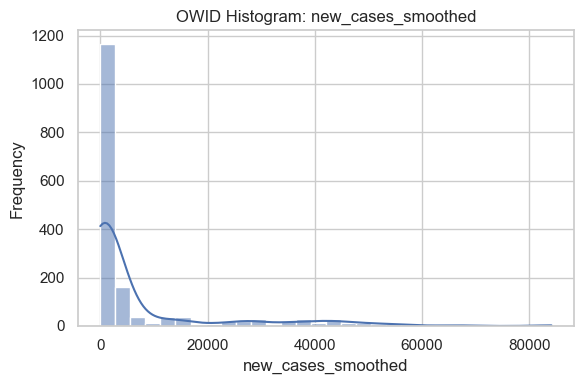

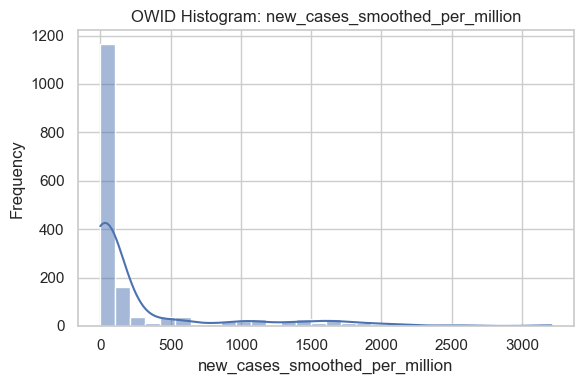

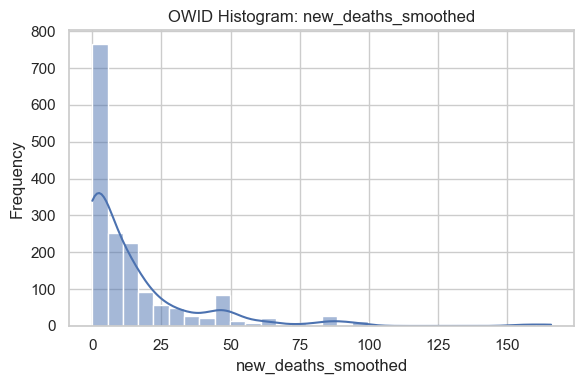

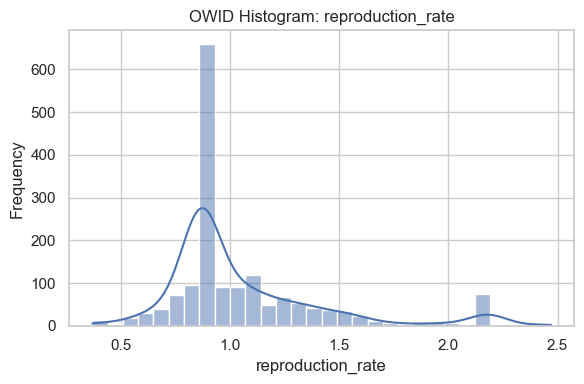

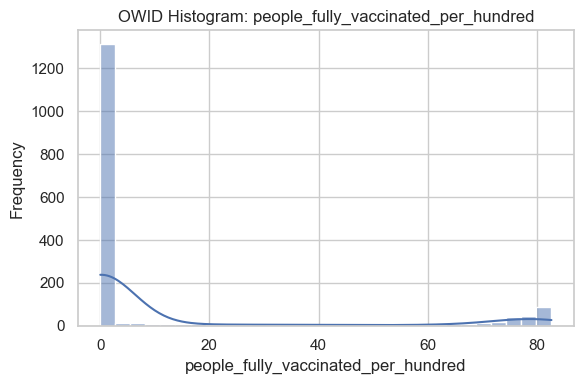

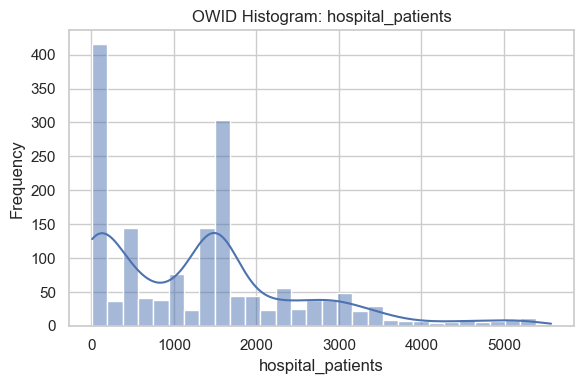

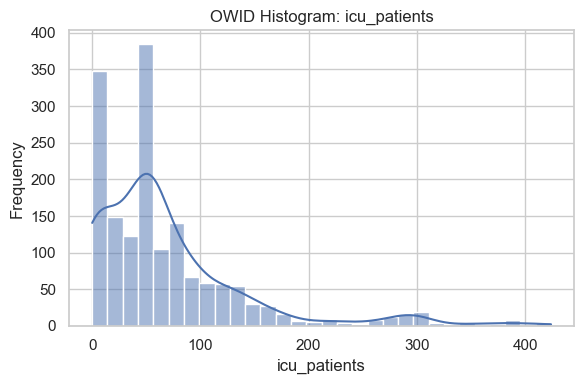

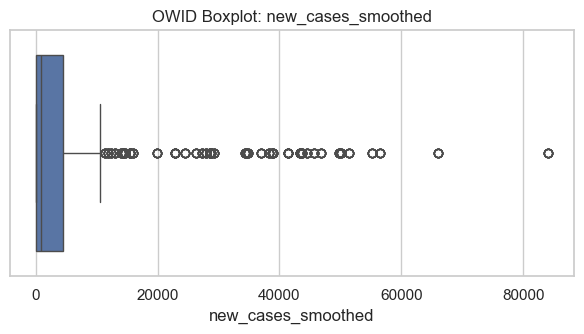

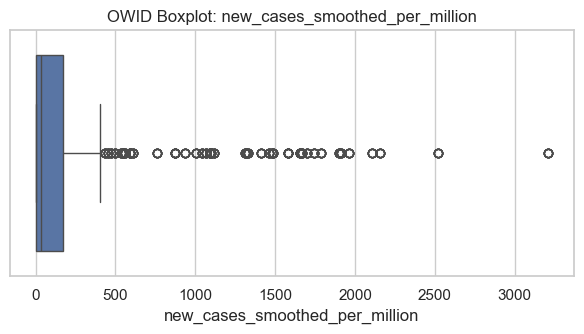

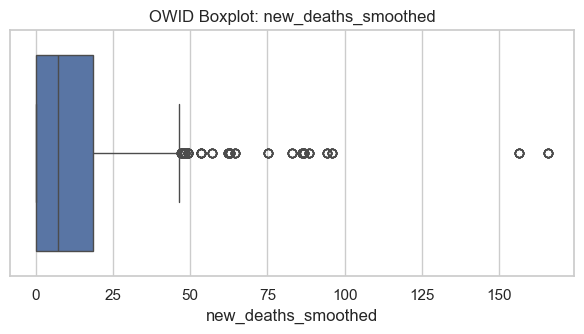

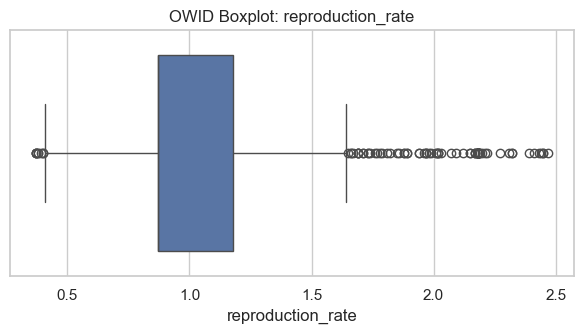

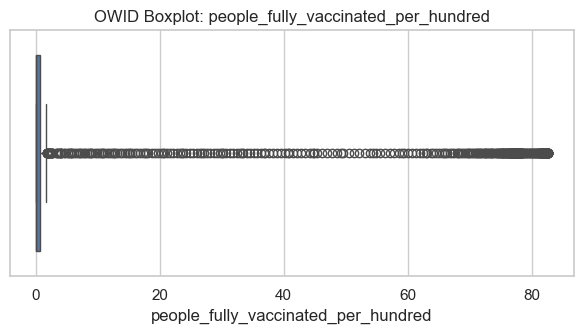

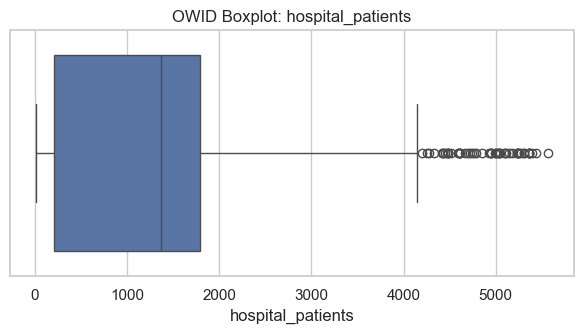

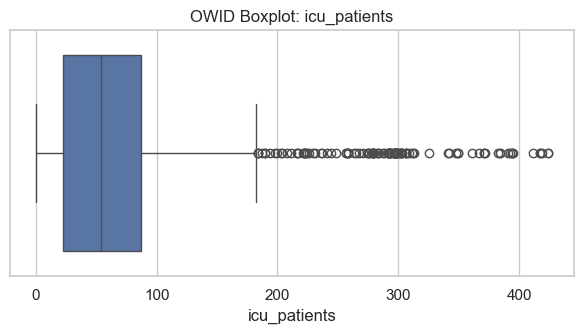

In [27]:
# Numeric variable
plot_histograms(owid, x_epi, "OWID Histogram")
plot_boxplots(owid, x_epi, "OWID Boxplot")

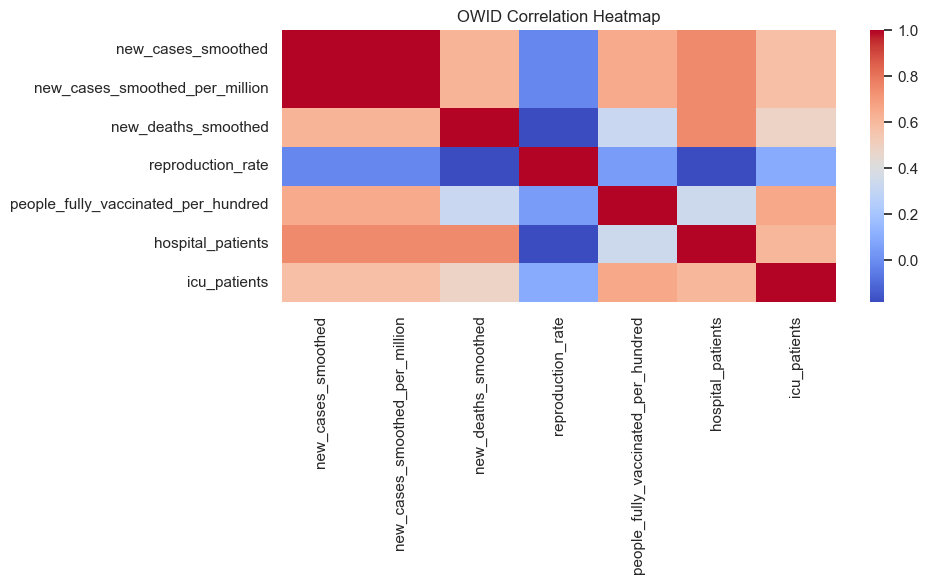

In [28]:
# Correlation heatmap
plot_corr_heatmap(
    owid,
    x_epi,
    "OWID Correlation Heatmap",
    figsize=(10, 6)
)

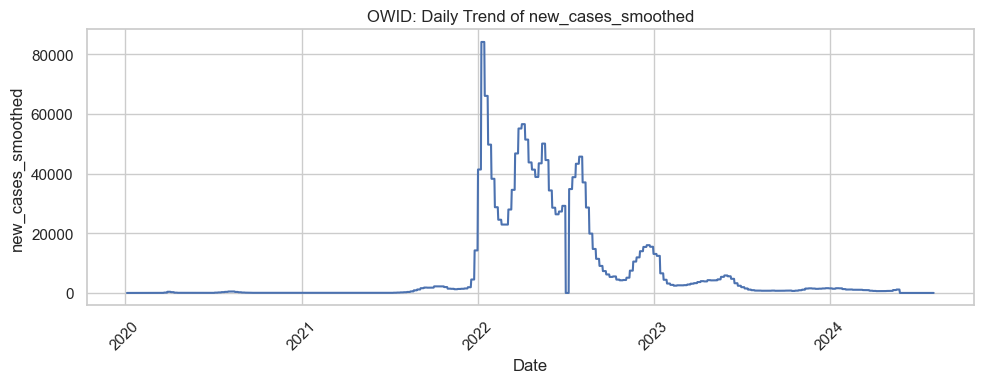

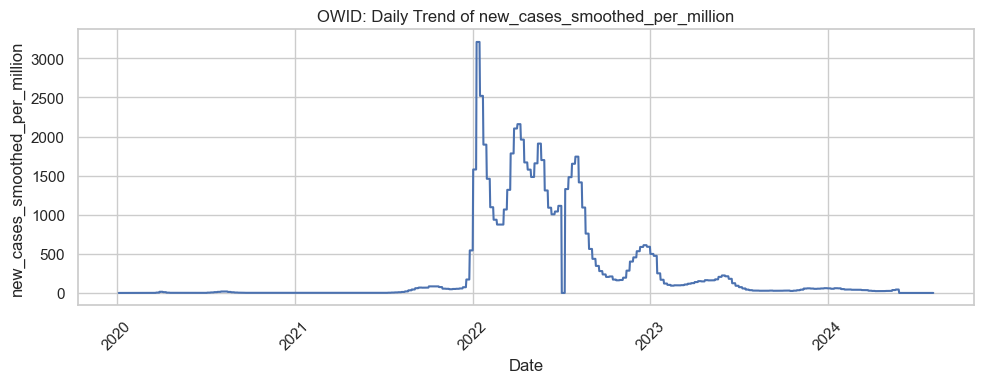

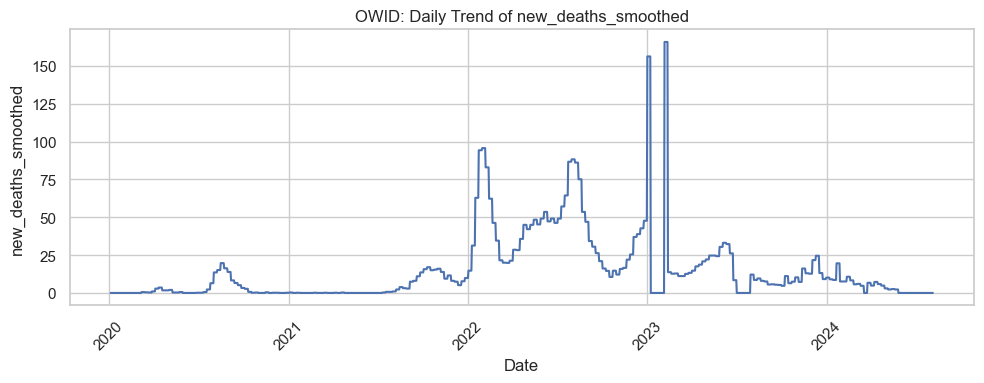

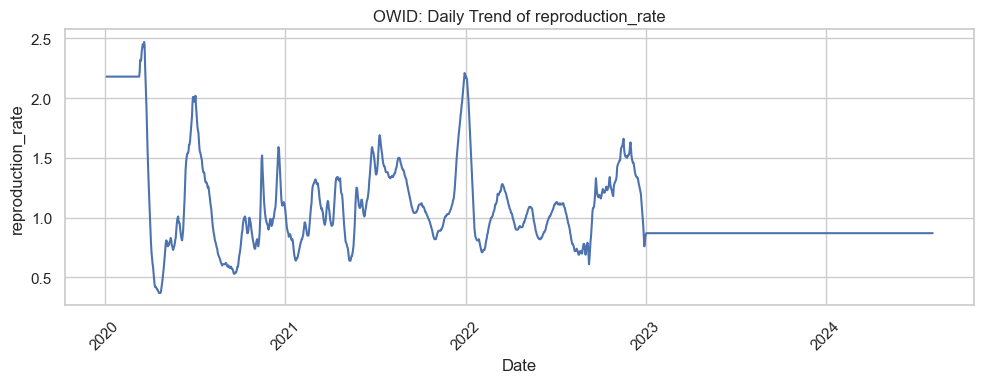

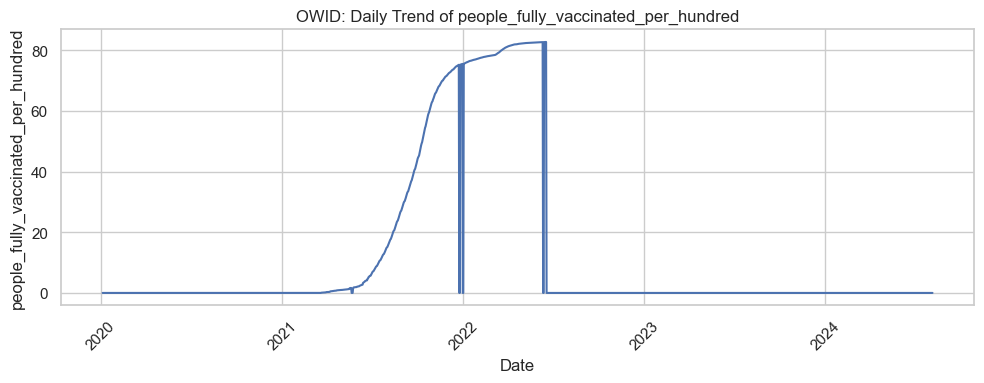

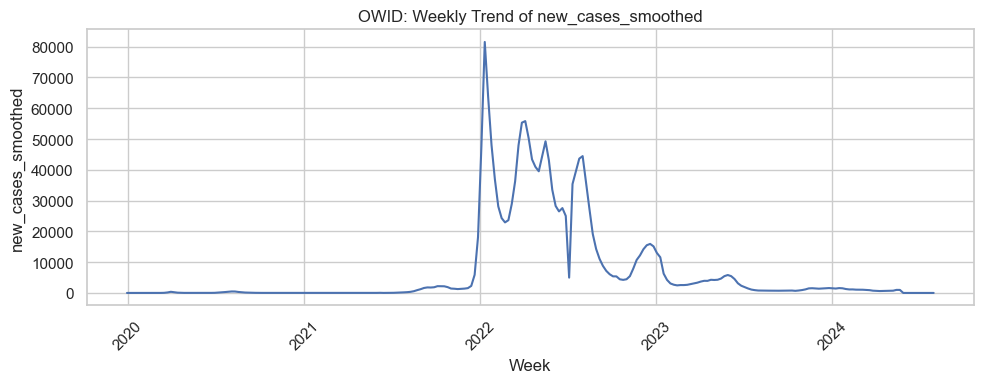

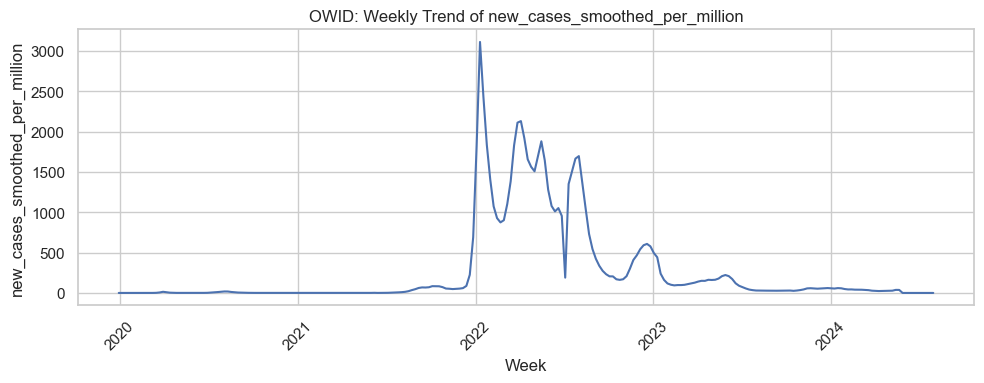

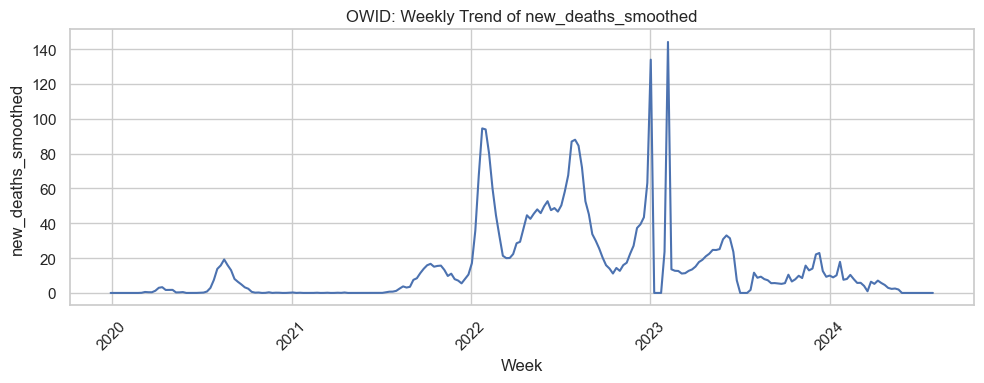

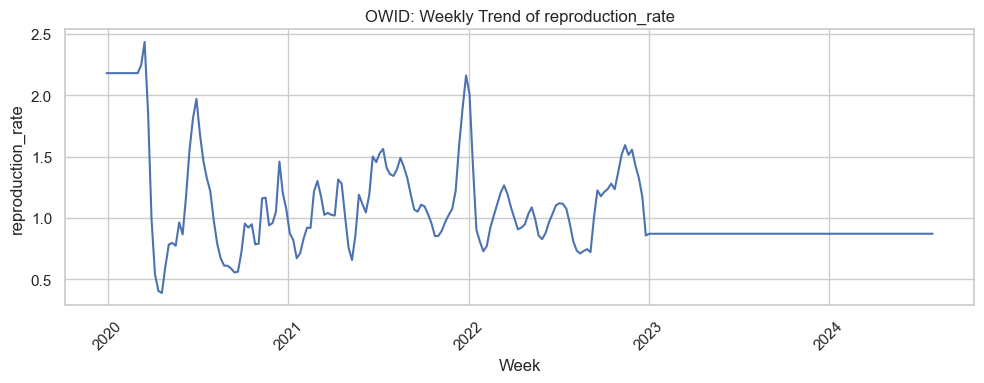

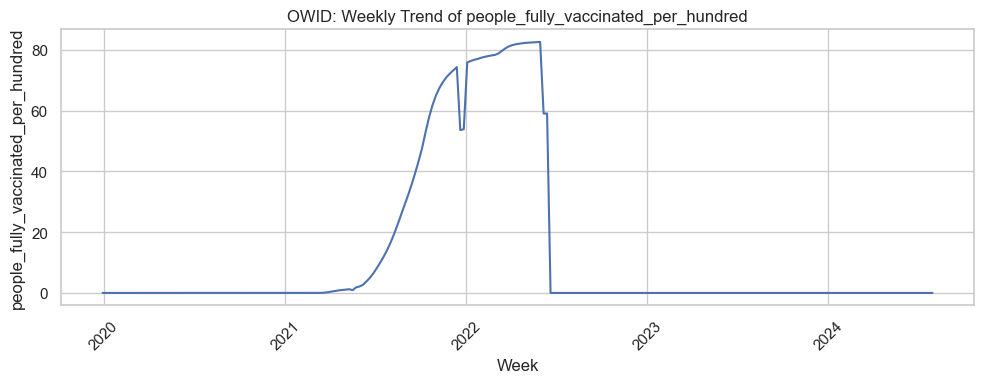

In [29]:
# Time trend
owid_daily = plot_daily_means(
    owid,
    [
        "new_cases_smoothed",
        "new_cases_smoothed_per_million",
        "new_deaths_smoothed",
        "reproduction_rate",
        "people_fully_vaccinated_per_hundred"
    ],
    "OWID"
)

owid_weekly = plot_weekly_means(
    owid,
    [
        "new_cases_smoothed",
        "new_cases_smoothed_per_million",
        "new_deaths_smoothed",
        "reproduction_rate",
        "people_fully_vaccinated_per_hundred"
    ],
    "OWID"
)

# Merging Data

In [30]:
# Merge YouGov + OxCGRT
merged_df = yougov.merge(
    oxcgrt,
    on="date",
    how="left"
)

merged_df.head()

,date,survey_week,survey_weight,age,gender,state,household_size,employment_status,mask_wearing,wash_hands,use_sanitiser,avoid_going_out,avoid_public_transport,avoid_crowded_areas,would_self_isolate,willingness_self_isolate,handwashing_frequency,times_left_home,covid_dangerous_for_me,likely_to_get_covid,important_to_improve_health,life_affected_by_covid,trust_in_government_handling,mask_policy,stay_home_requirement,internal_movement_restriction,gathering_restriction,cancel_public_events,workplace_closing,public_transport_closure,international_travel_controls,public_information_campaign,testing_policy,contact_tracing,stringency_index
0,2020-04-01,week 1,0.678531,44,Male,Queensland,2,Not working - looking for work,2,5.0,4,5,5,5,1.0,5.0,6,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3
1,2020-04-01,week 1,1.049460,66,Male,Victoria,1,Retired,1,5.0,4,3,5,4,1.0,5.0,20,2,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3
2,2020-04-01,week 1,1.271203,22,Male,Victoria,3,Working part time (8-34 hours a week),5,5.0,5,3,5,5,1.0,5.0,10,1,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3
3,2020-04-01,week 1,0.936885,45,Male,New South Wales,3,Working full time (35 or more hours per week),5,4.0,4,4,5,4,1.0,5.0,10,1,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3
4,2020-04-01,week 1,0.762042,42,Female,Victoria,3,Working part time (8-34 hours a week),1,5.0,3,5,5,5,1.0,4.0,4,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3


In [31]:
# Merge the result + OWID
merged = merged_df.merge(
    owid,
    on="date",
    how="left"
)

merged.head()

,date,survey_week,survey_weight,age,gender,state,household_size,employment_status,mask_wearing,wash_hands,use_sanitiser,avoid_going_out,avoid_public_transport,avoid_crowded_areas,would_self_isolate,willingness_self_isolate,handwashing_frequency,times_left_home,covid_dangerous_for_me,likely_to_get_covid,important_to_improve_health,life_affected_by_covid,trust_in_government_handling,mask_policy,stay_home_requirement,internal_movement_restriction,gathering_restriction,cancel_public_events,workplace_closing,public_transport_closure,international_travel_controls,public_information_campaign,testing_policy,contact_tracing,stringency_index,new_cases_smoothed,new_cases_smoothed_per_million,new_deaths_smoothed,reproduction_rate,people_fully_vaccinated_per_hundred,hospital_patients,icu_patients
0,2020-04-01,week 1,0.678531,44,Male,Queensland,2,Not working - looking for work,2,5.0,4,5,5,5,1.0,5.0,6,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0
1,2020-04-01,week 1,1.049460,66,Male,Victoria,1,Retired,1,5.0,4,3,5,4,1.0,5.0,20,2,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0
2,2020-04-01,week 1,1.271203,22,Male,Victoria,3,Working part time (8-34 hours a week),5,5.0,5,3,5,5,1.0,5.0,10,1,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0
3,2020-04-01,week 1,0.936885,45,Male,New South Wales,3,Working full time (35 or more hours per week),5,4.0,4,4,5,4,1.0,5.0,10,1,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0
4,2020-04-01,week 1,0.762042,42,Female,Victoria,3,Working part time (8-34 hours a week),1,5.0,3,5,5,5,1.0,4.0,4,0,7,4,7,4,3,0,1,2,4,2,2,0,4,2,1,2,71.3,389.71,14.87,1.0,1.09,0.0,441.0,86.0


In [32]:
# Merged data columns
merged_cols = y_vars + x_yougov + x_policy + x_epi
merged_cols = [c for c in merged_cols if c in merged.columns]

## Merged Data EDA

In [33]:
# Sort by date
merged = merged.sort_values("date").reset_index(drop=True)

In [34]:
# Check result
print("Merged shape:", merged.shape)
print("\nMissing values after merge:")
print(merged.isna().sum().sort_values(ascending=False))

Merged shape: (53833, 42)

Missing values after merge:
would_self_isolate                     5635
willingness_self_isolate               2068
wash_hands                             1006
survey_weight                             0
survey_week                               0
age                                       0
state                                     0
household_size                            0
gender                                    0
date                                      0
mask_wearing                              0
employment_status                         0
use_sanitiser                             0
avoid_going_out                           0
avoid_crowded_areas                       0
avoid_public_transport                    0
handwashing_frequency                     0
times_left_home                           0
covid_dangerous_for_me                    0
likely_to_get_covid                       0
important_to_improve_health               0
life_affected_by_covi

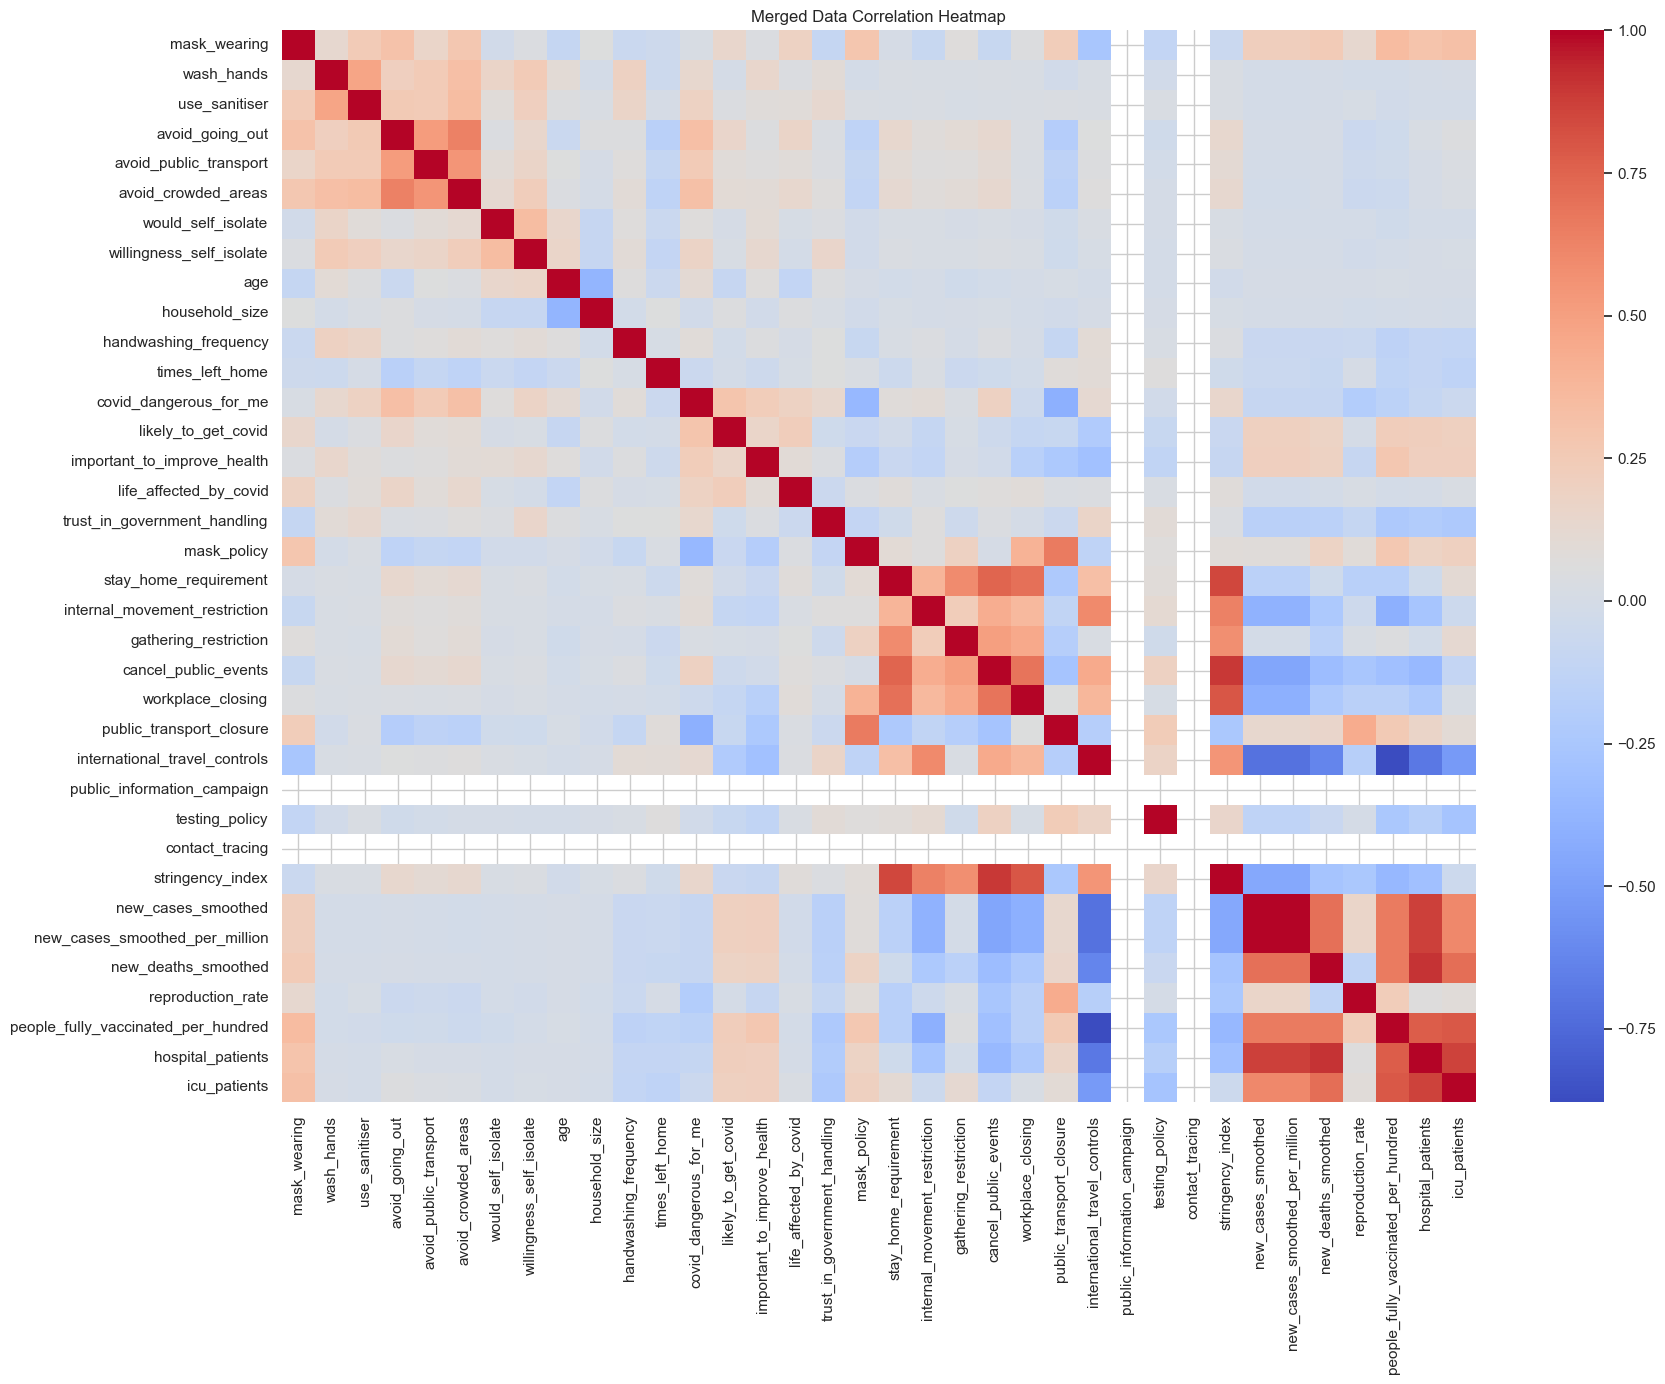

In [35]:
# Correlation Heatmap
plot_corr_heatmap(
    merged,
    merged_cols,
    "Merged Data Correlation Heatmap",
    figsize=(18, 14)
)

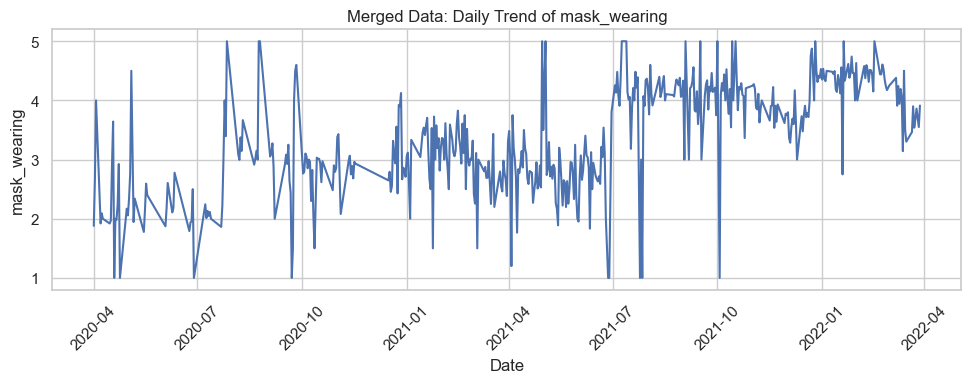

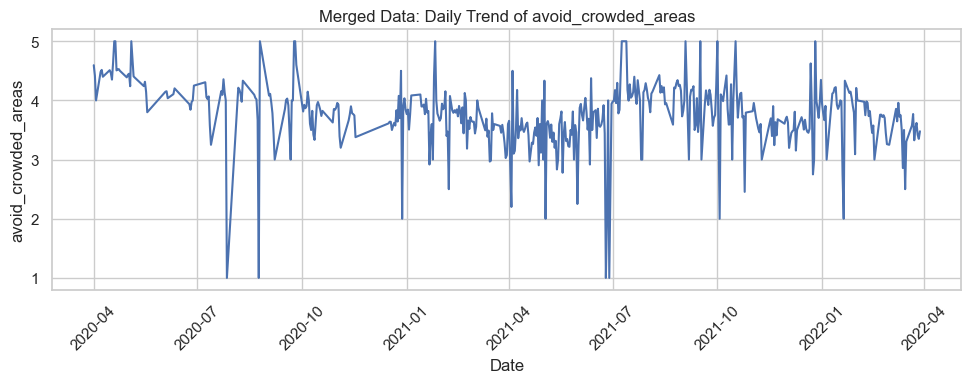

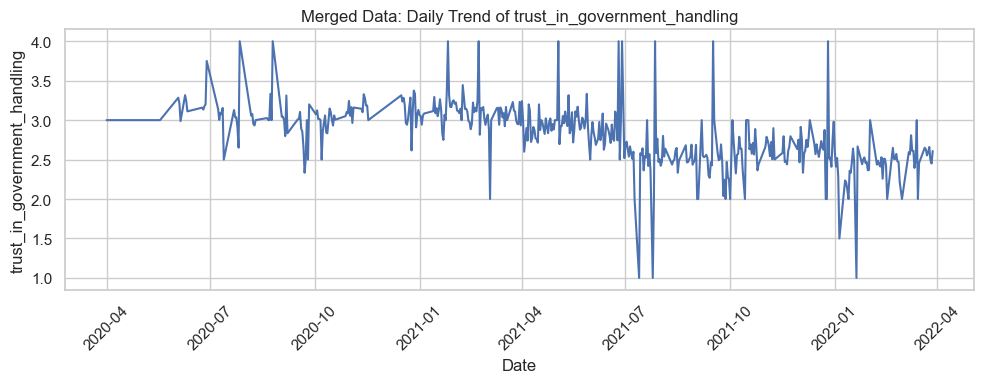

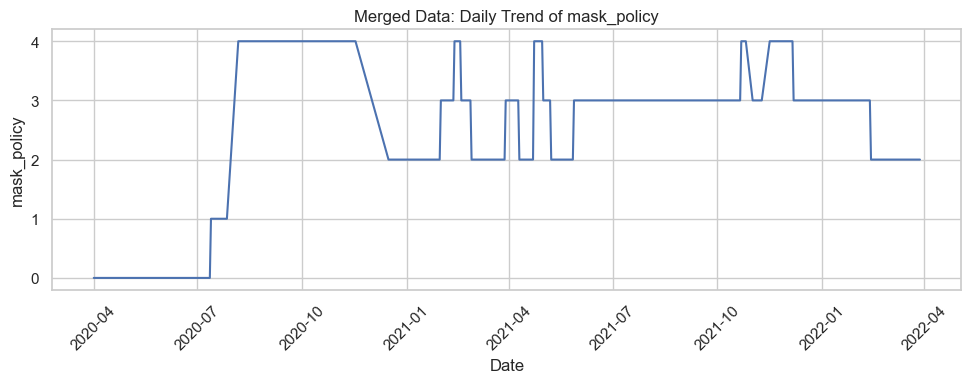

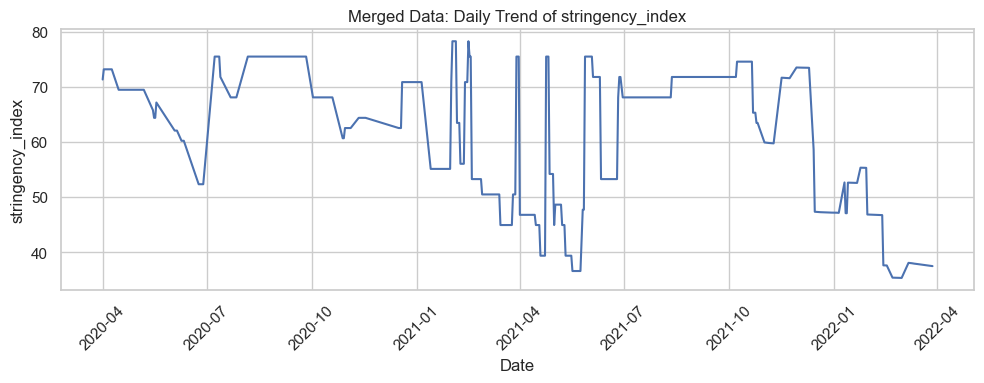

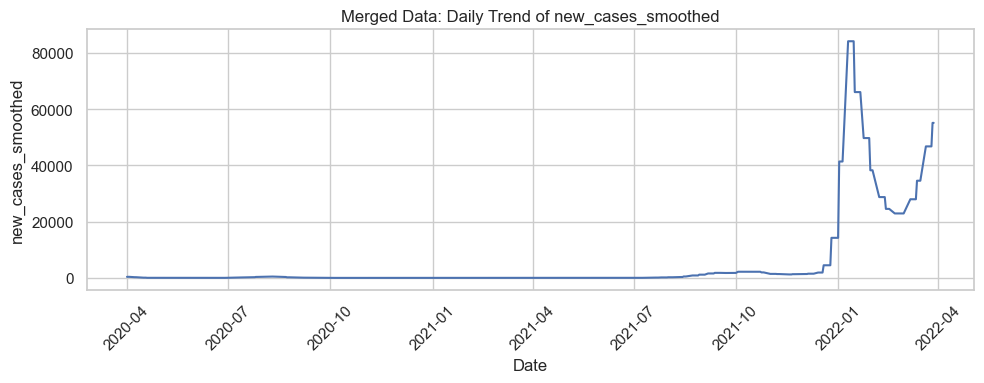

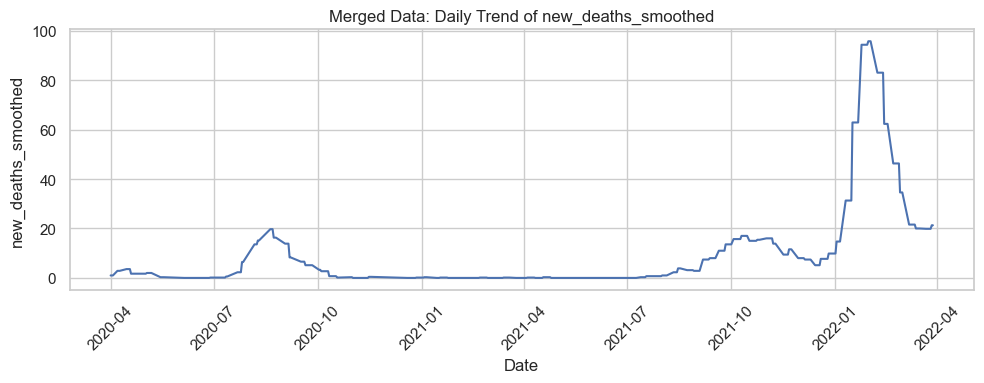

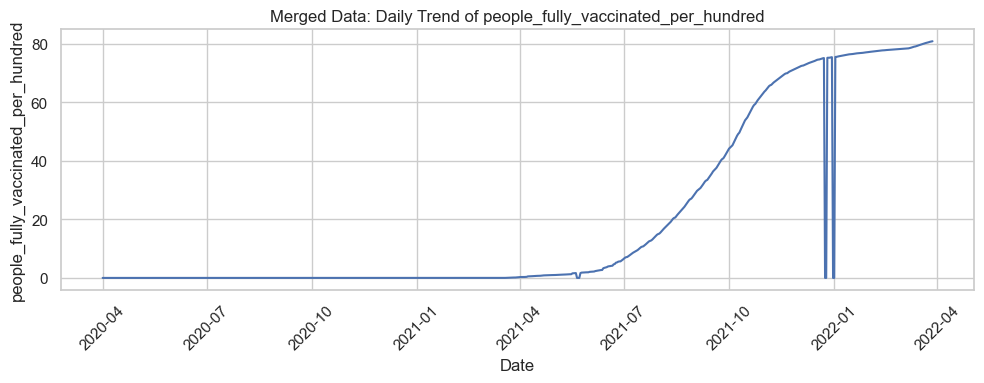

In [36]:
# Daily Trends (Individual)
merged_daily = plot_daily_means(
    merged,
    [
        "mask_wearing",
        "avoid_crowded_areas",
        "trust_in_government_handling",
        "mask_policy",
        "stringency_index",
        "new_cases_smoothed",
        "new_deaths_smoothed",
        "people_fully_vaccinated_per_hundred"
    ],
    "Merged Data"
)

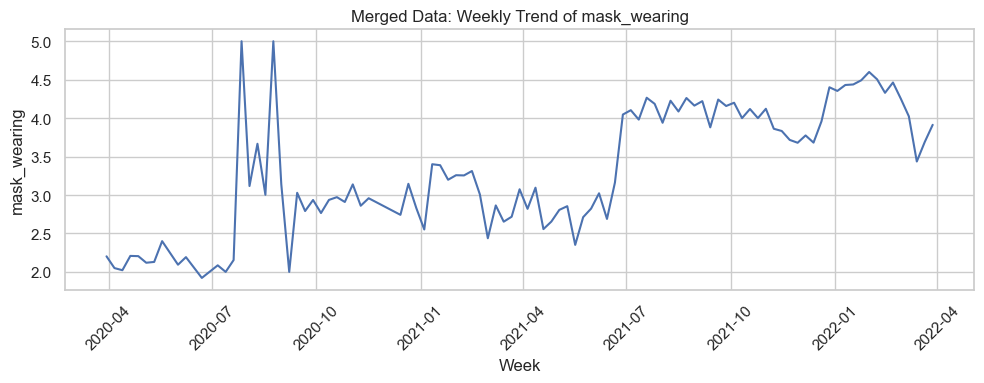

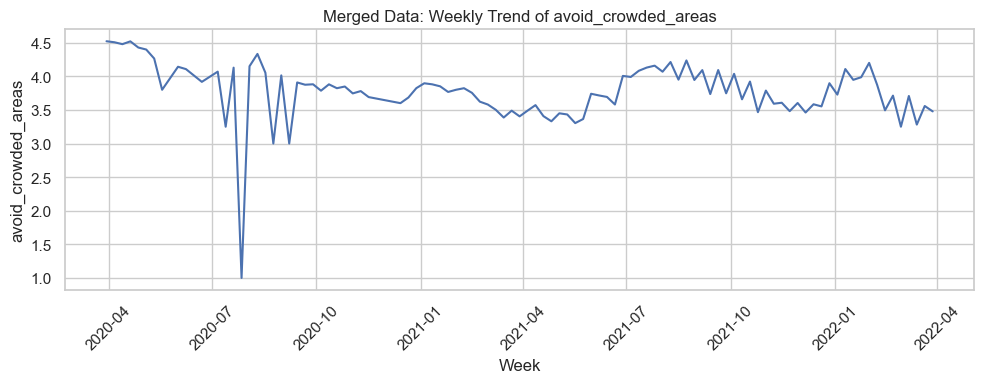

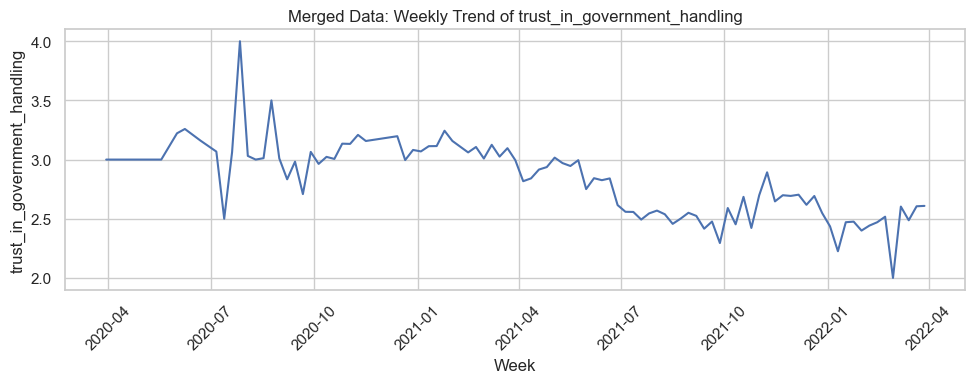

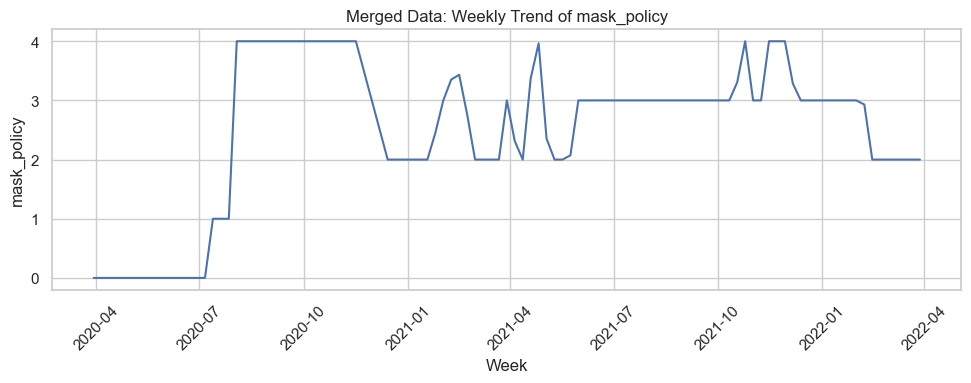

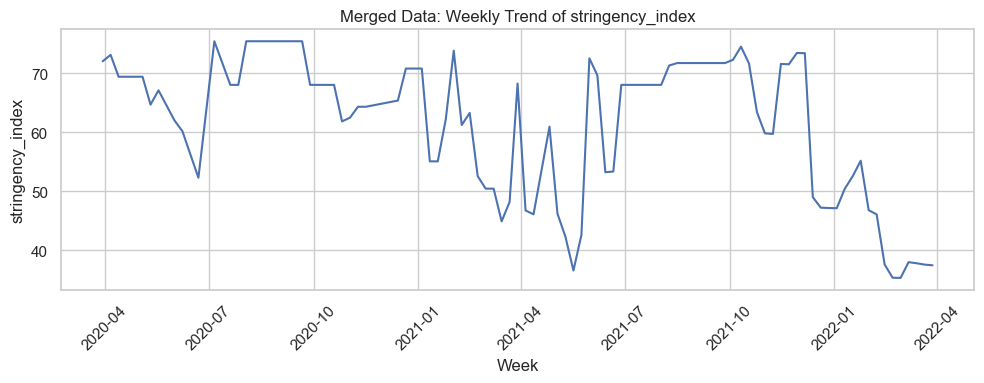

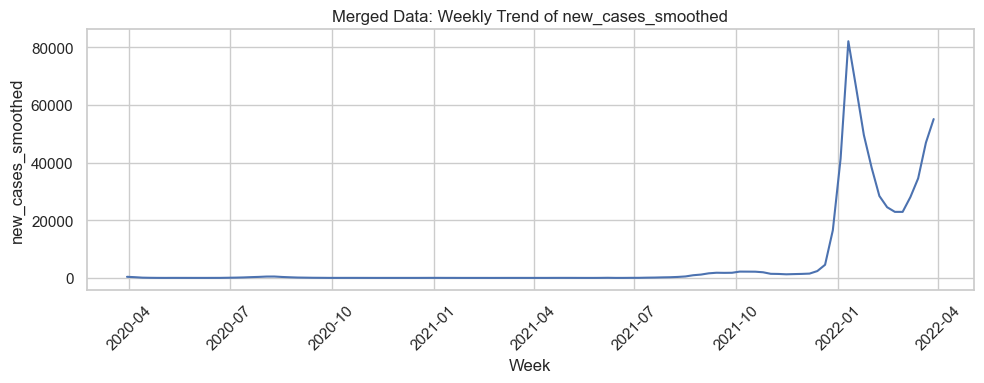

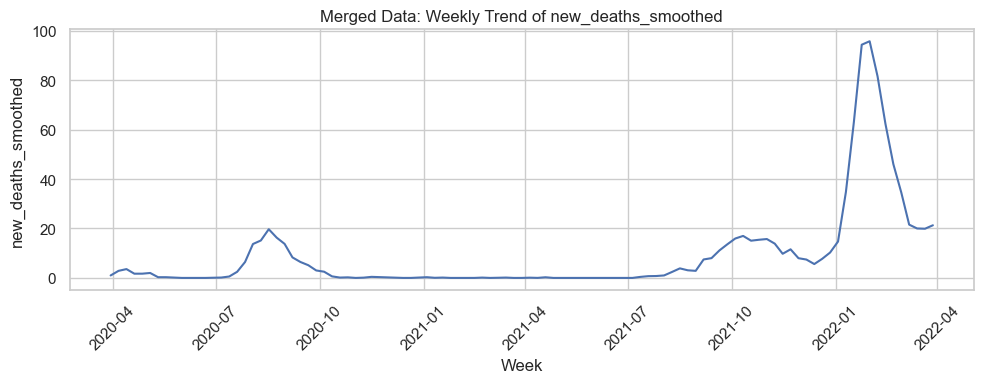

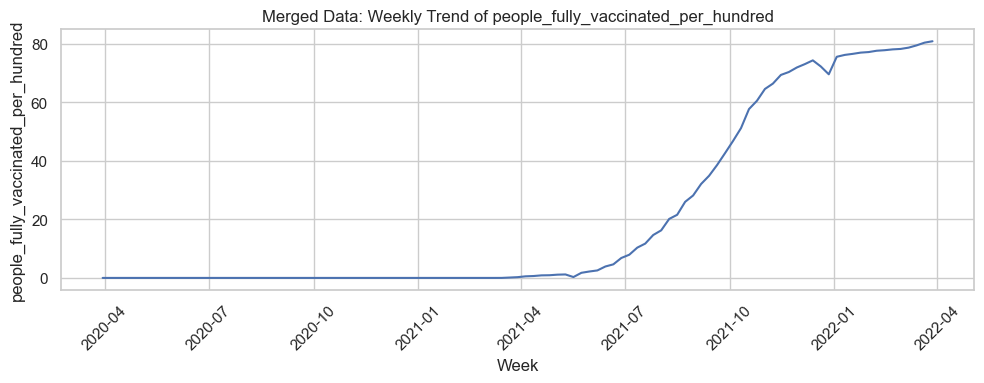

In [37]:
# Weekly Trends (Individual)
merged_weekly = plot_weekly_means(
    merged,
    [
        "mask_wearing",
        "avoid_crowded_areas",
        "trust_in_government_handling",
        "mask_policy",
        "stringency_index",
        "new_cases_smoothed",
        "new_deaths_smoothed",
        "people_fully_vaccinated_per_hundred"
    ],
    "Merged Data"
)

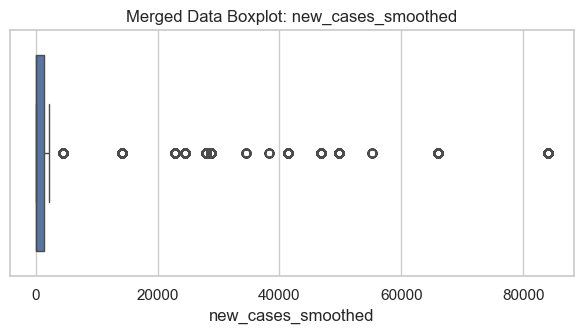

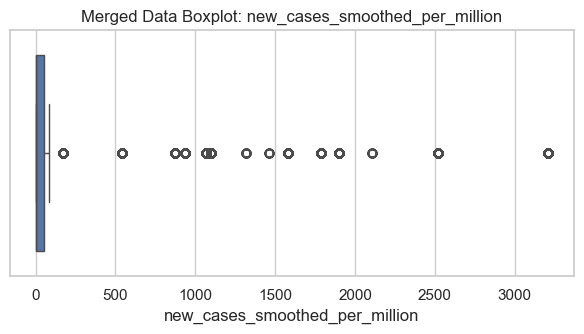

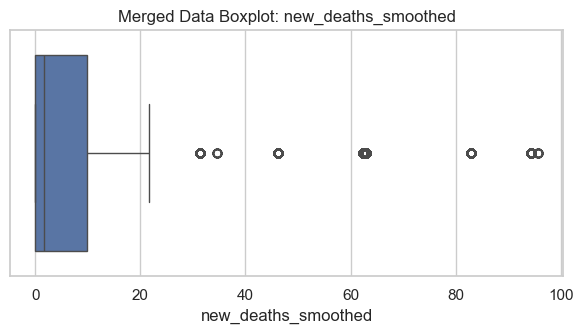

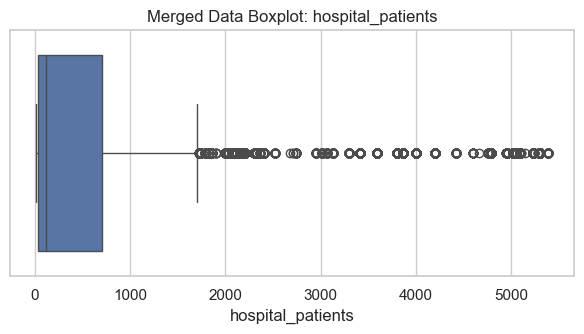

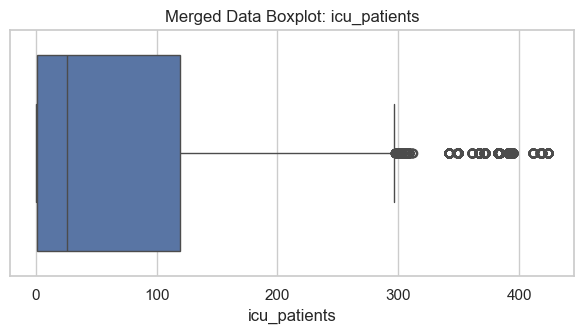

In [38]:
# Log transformation
log_vars = [
    "new_cases_smoothed",
    "new_cases_smoothed_per_million",
    "new_deaths_smoothed",
    "hospital_patients",
    "icu_patients"
]

for col in log_vars:
    if col in merged.columns:
        merged[col] = merged[col].clip(lower=0)
        merged[f"log_{col}"] = np.log1p(merged[col])

plot_boxplots(merged, log_vars, "Merged Data Boxplot")

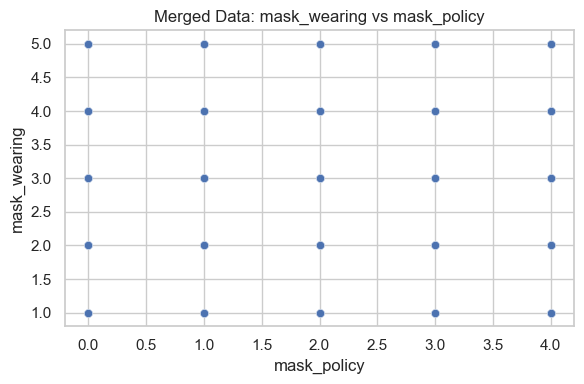

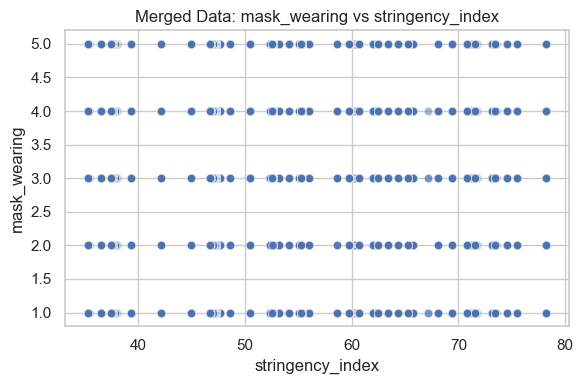

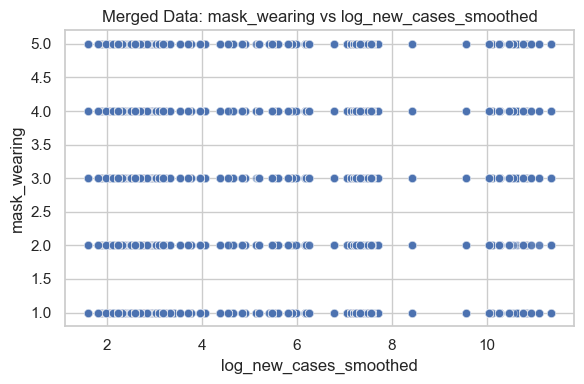

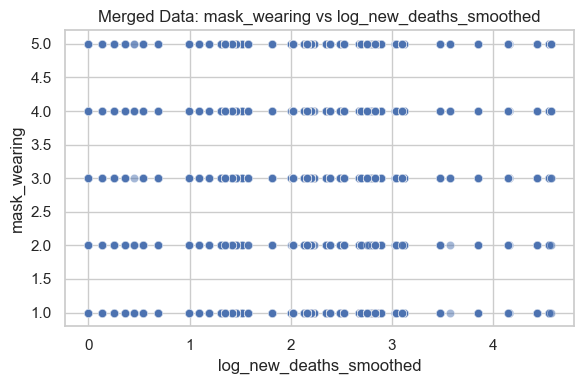

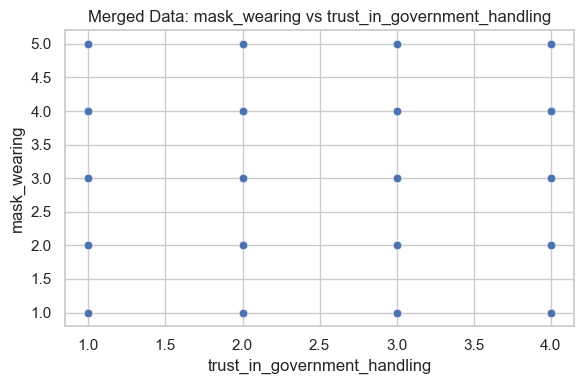

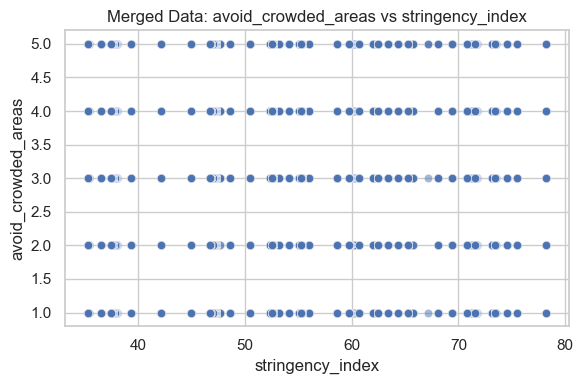

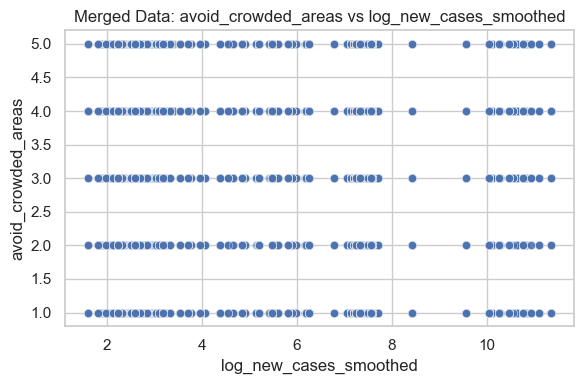

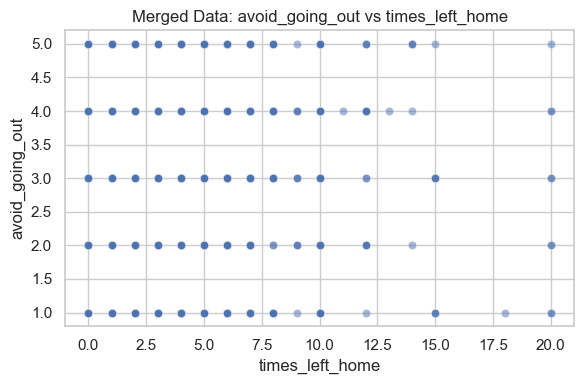

In [39]:
# Scatter Plots
scatter_pairs = [
    ("mask_policy", "mask_wearing"),
    ("stringency_index", "mask_wearing"),
    ("log_new_cases_smoothed", "mask_wearing"),
    ("log_new_deaths_smoothed", "mask_wearing"),
    ("trust_in_government_handling", "mask_wearing"),
    ("stringency_index", "avoid_crowded_areas"),
    ("log_new_cases_smoothed", "avoid_crowded_areas"),
    ("times_left_home", "avoid_going_out")
]

plot_scatter_pairs(merged, scatter_pairs, "Merged Data")

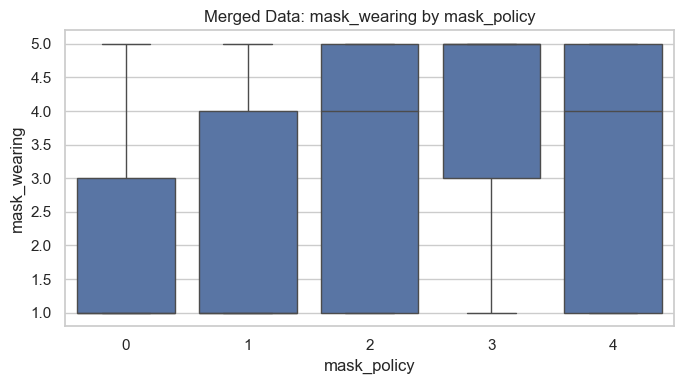

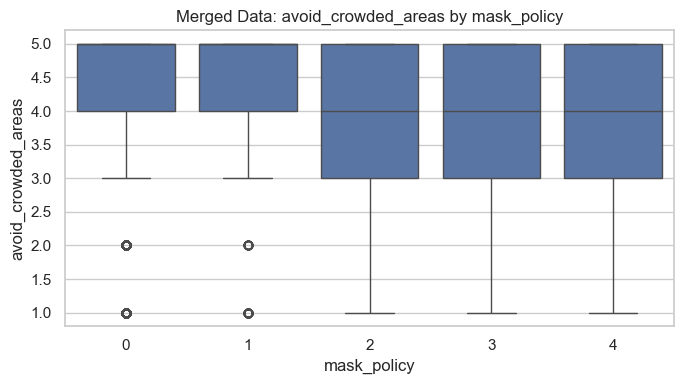

In [40]:
# Boxplots (Behaviour vs Policy)
boxplot_pairs = [
    ("mask_wearing", "mask_policy"),
    ("avoid_crowded_areas", "mask_policy")
]

plot_boxplot_pairs(merged, boxplot_pairs, "Merged Data")

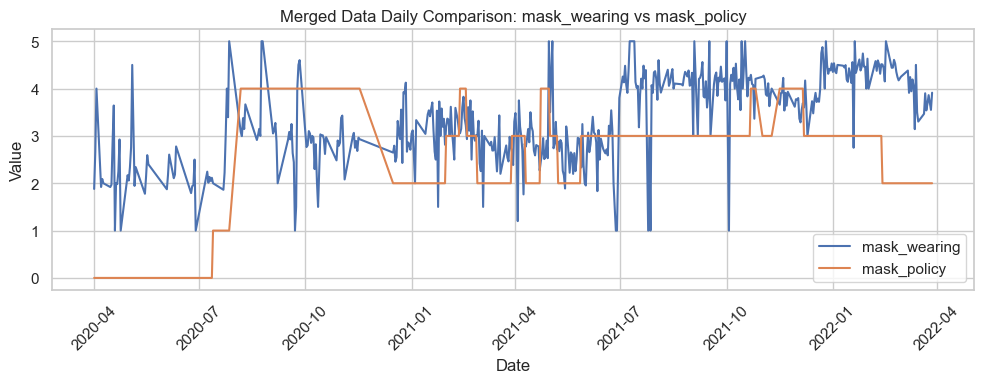

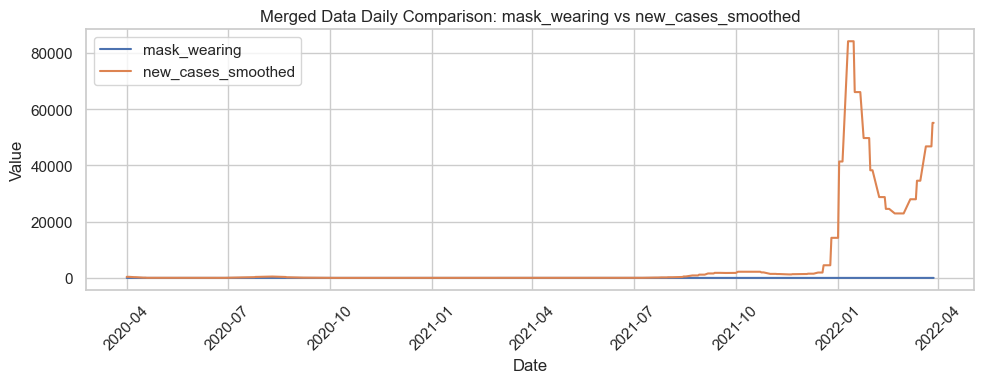

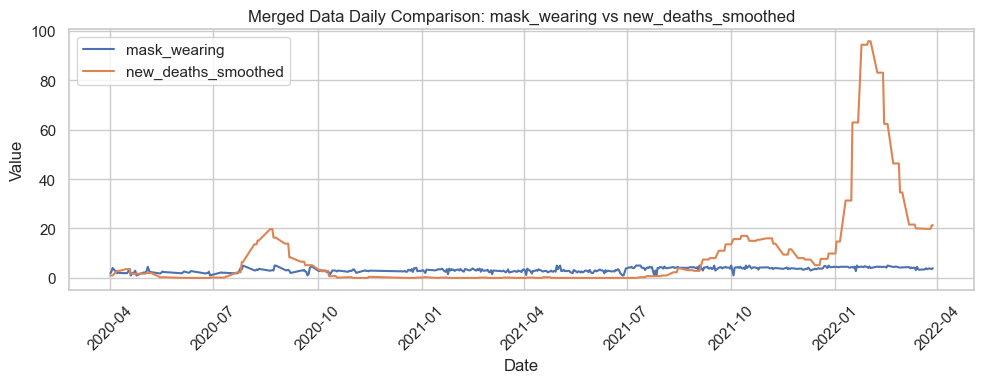

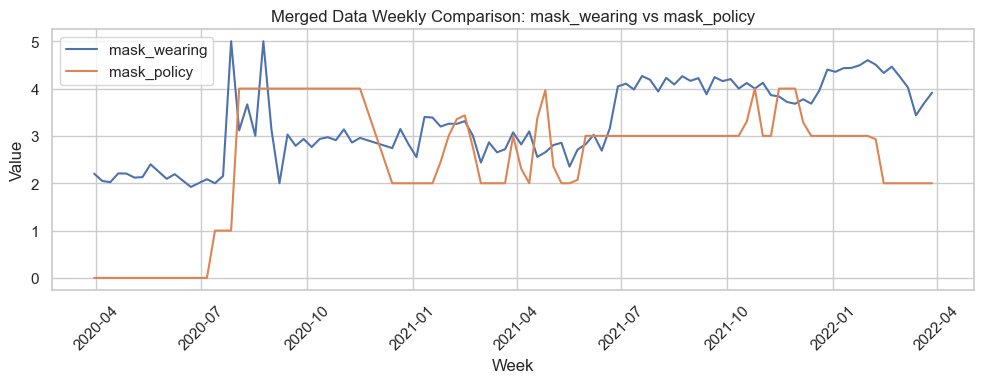

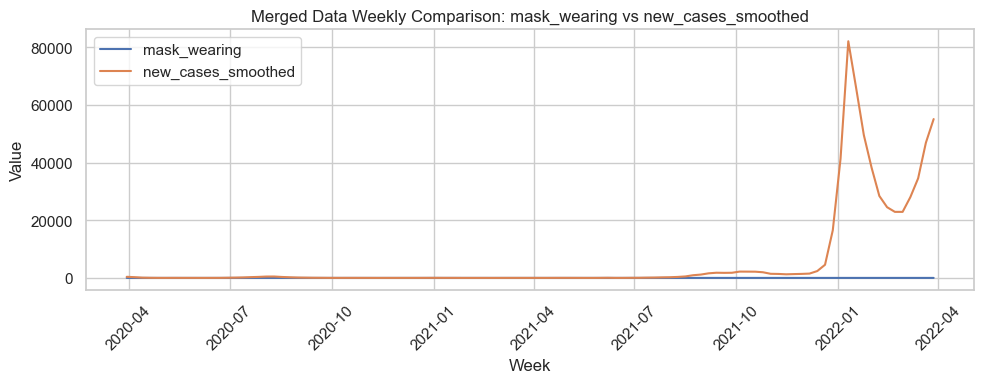

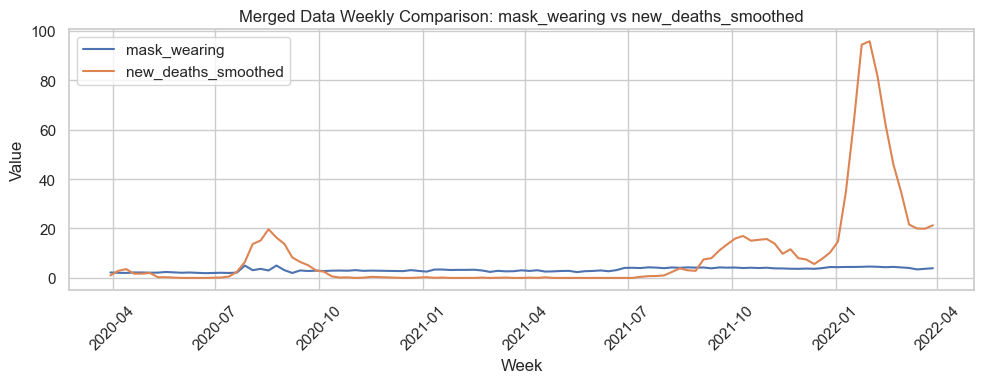

In [41]:
# Comaprison variables
comparison_pairs = [
    ("mask_wearing", "mask_policy"),
    ("mask_wearing", "new_cases_smoothed"),
    ("mask_wearing", "new_deaths_smoothed")
]

# Daily Comparison
plot_time_comparison(merged, comparison_pairs, "Merged Data Daily Comparison")

# Weekly Comparison
plot_weekly_comparison(merged, comparison_pairs, "Merged Data Weekly Comparison")

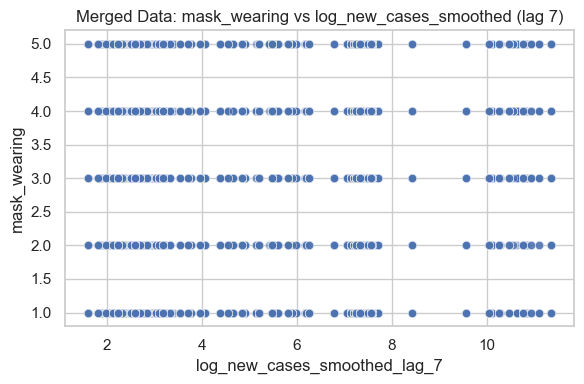

In [42]:
# Lag Analysis
plot_lag_scatter(
    merged,
    y_col="mask_wearing",
    x_col="log_new_cases_smoothed",
    lag_days=7,
    title_prefix="Merged Data"
)

# Exporting Data

In [43]:
# Saving the merged data as csv
csv_name = 'Protective Behaviour Data (A).csv'
merged.to_csv(csv_name, index=False)